In [78]:
%pip install -r ../requirements.txt

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import torch
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [18]:
# ---- CONFIG ----
# Global configuration container for model search, training, and threshold tuning.

CONFIG = {

    # ---- Hyperparameter Search Space ----
    # Defines candidate values for architecture selection / tuning
    "search_space": {
        # Hidden layer size for encoder/decoder LSTM
        "hidden_dim": [64, 128],

        # Latent bottleneck dimensionality
        "latent_dim": [4],

        # Number of stacked LSTM layers
        "num_layers": [1],

        # Sliding window sequence lengths for time-series segmentation
        "seq_len": np.arange(64, 352, 32)
    },

    # ---- Training Configuration ----
    # Controls optimization and training stability behavior
    "train": {
        # Maximum training epochs per run
        "epochs": 50,

        # Mini-batch size for gradient updates
        "batch_size": 64,

        # Optimizer learning rate
        "lr": 1e-3,

        # Early stopping: epochs without improvement before stopping
        "early_stopping_patience": 10,

        # LR scheduler patience before decay trigger
        "scheduler_patience": 3,

        # Multiplicative decay factor for LR scheduler
        "scheduler_factor": 0.5,

        # Lower bound for learning rate decay
        "min_lr": 1e-6
    },

    # ---- Threshold Calibration ----
    # Percentile grid used to select anomaly detection threshold
    "threshold_percentiles": np.arange(30, 100, 1)
}

In [19]:
# ---- MODEL ----
class LSTMAutoencoder(nn.Module):
    """
    LSTM Autoencoder for sequence reconstruction.
    Learns compact latent representation of time-series data.
    """

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        latent_dim=16,
        num_layers=1
    ):
        super().__init__()

        self.num_layers = num_layers

        # ---- Encoder ----
        # Maps input sequence → hidden representation
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # ---- Latent Bottleneck ----
        # Compress encoder hidden state into latent space
        self.to_latent = nn.Linear(hidden_dim, latent_dim)

        # Expand latent vector back to decoder hidden space
        self.from_latent = nn.Linear(latent_dim, hidden_dim)

        # ---- Decoder ----
        # Reconstruct sequence from latent-conditioned input
        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # ---- Output Projection ----
        # Map decoder hidden states back to input feature space
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):

        # ---- Encode Sequence ----
        _, (h, _) = self.encoder(x)

        # Take last layer hidden state as sequence summary
        z = self.to_latent(h[-1])

        # ---- Latent Expansion ----
        # Convert latent vector into decoder initial representation
        h_dec = self.from_latent(z)

        # Sequence length for reconstruction
        seq_len = x.shape[1]

        # Repeat latent representation across time dimension
        dec_in = h_dec.unsqueeze(1).repeat(1, seq_len, 1)

        # Initialize decoder hidden state from latent vector
        h0 = h_dec.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        # ---- Decode Sequence ----
        out, _ = self.decoder(dec_in, (h0, c0))

        # ---- Reconstruct Output ----
        return self.output_layer(out)

In [20]:
# ---- DATA LOADING ----
# Responsible for reading raw time-series data, normalization,
# loading anomaly windows, and constructing supervised labels.

def load_series(path):
    # Read CSV and parse timestamps
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Ensure chronological order for time-series consistency
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Select only numerical features for modeling
    num_cols = df.select_dtypes(include=["number"]).columns

    # Standardize numerical features (zero mean, unit variance)
    df[num_cols] = (
        (df[num_cols] - df[num_cols].mean())
        / df[num_cols].std()
    )

    return df


def load_windows(path, key):
    # Load labeled anomaly intervals from JSON file
    with open(path, "r") as f:
        return json.load(f)[key]


def build_labels(df, windows):
    # Initialize binary label vector (0 = normal, 1 = anomaly)
    y = np.zeros(len(df))

    # Convert time windows into point-wise labels
    for s, e in windows:
        s = pd.to_datetime(s)
        e = pd.to_datetime(e)

        # Create mask for all timestamps within anomaly window
        mask = (
            (df["timestamp"] >= s) &
            (df["timestamp"] <= e)
        )

        y[mask] = 1

    # Attach labels to dataframe
    df["label"] = y

    return df

In [21]:
# ---- WINDOWING ----
# Converts time-series into overlapping sliding windows for sequence modeling.
# Each window inherits a label based on presence of any anomaly inside it.

def make_windows(values, labels, seq_len):

    # Ensure consistent array format for slicing
    values = np.asarray(values).reshape(-1, 1)
    labels = np.asarray(labels)

    # Number of possible sliding windows
    n = len(values) - seq_len + 1

    # Pre-allocate tensors for efficiency
    x = np.zeros((n, seq_len, 1), dtype=np.float32)
    y = np.zeros(n, dtype=np.float32)

    # ---- Sliding Window Construction ----
    for i in range(n):
        # Input sequence window
        x[i] = values[i:i + seq_len]

        # Label aggregation (OR over window)
        # If any timestep is anomalous → window is anomalous
        y[i] = np.max(labels[i:i + seq_len])

    return x, y

In [22]:
# %%
# ---- SPLIT ----
# Train:
#   - all normal windows only
#
# Test:
#   - entire dataset (normal + anomaly)

def split_windows(x, y):

    # ---- Normal Samples Only For Training ----
    train_idx = np.where(y == 0)[0]

    # ---- Full Dataset For Testing ----
    test_idx = np.arange(len(y))

    # Shuffle training indices
    np.random.shuffle(train_idx)

    return train_idx, test_idx

In [23]:
# ---- METRICS ----
# Evaluates anomaly detection performance at a given threshold.
# Converts continuous anomaly scores into binary predictions.

def metrics(y_true, scores, thr):

    # ---- Thresholding ----
    # Convert anomaly scores into binary predictions
    pred = (scores > thr).astype(int)

    # ---- Classification Metrics ----
    # Precision: correctness of detected anomalies
    # Recall: coverage of actual anomalies
    # F1: harmonic mean of precision and recall
    return (
        precision_score(y_true, pred, zero_division=0),
        recall_score(y_true, pred, zero_division=0),
        f1_score(y_true, pred, zero_division=0)
    )

In [24]:
# ---- SEED ----
# Ensures reproducibility across Python, NumPy, and PyTorch.

def set_seed(seed):

    # Python RNG seed
    random.seed(seed)

    # NumPy RNG seed
    np.random.seed(seed)

    # PyTorch CPU seed
    torch.manual_seed(seed)

    # PyTorch GPU seed (all devices)
    torch.cuda.manual_seed_all(seed)

In [25]:
# %%
# ---- TRAIN ----

def train(model, x_train, device):

    # ---- Device Setup ----
    model = model.to(device)

    # ---- Optimizer ----
    opt = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["train"]["lr"]  # type: ignore
    )

    # ---- LR Scheduler ----
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=CONFIG["train"]["scheduler_factor"],  # type: ignore
        patience=CONFIG["train"]["scheduler_patience"],  # type: ignore
        min_lr=CONFIG["train"]["min_lr"],  # type: ignore
    )

    # ---- Loss Function ----
    loss_fn = nn.MSELoss()

    # ---- DataLoader ----
    loader_tr = DataLoader(
        TensorDataset(torch.tensor(x_train)),
        batch_size=CONFIG["train"]["batch_size"],  # type: ignore
    )

    train_losses = []

    # ---- Training Loop ----
    for ep in range(CONFIG["train"]["epochs"]):  # type: ignore

        model.train()
        tr_loss = 0

        for (b,) in loader_tr:

            b = b.to(device)

            loss = loss_fn(model(b), b)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tr_loss += loss.item()

        tr_loss = tr_loss / len(loader_tr)
        train_losses.append(tr_loss)

        # ---- Scheduler Step ----
        scheduler.step(tr_loss)

        current_lr = opt.param_groups[0]["lr"]

        print(
            f"Epoch {ep+1} | "
            f"train_loss={tr_loss:.5f} | "
            f"lr={current_lr:.7f}"
        )

    # ---- Training Curve ----
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label="train_loss")
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

In [26]:
# ---- ERRORS ----
# Computes reconstruction error per sample using MSE.
# Used as anomaly score for threshold-based detection.

def get_errors(model, x, device):

    # ---- Eval Mode ----
    model.eval()

    # ---- Data Loader ----
    loader = DataLoader(
        TensorDataset(torch.tensor(x)),
        batch_size=256
    )

    errs = []

    # ---- No Gradient Inference ----
    with torch.no_grad():

        for (b,) in loader:

            b = b.to(device)

            # Forward pass (reconstruction)
            r = model(b)

            # ---- Per-sample reconstruction error ----
            # Mean over sequence length + feature dimension
            errs.append(
                torch.mean(
                    (r - b) ** 2,
                    dim=(1, 2)
                ).cpu()
            )

    # ---- Flatten results ----
    return torch.cat(errs).numpy()

In [27]:
# ---- VISUALIZATION ----
# Displays:
# 1) Original signal with anomaly points
# 2) Reconstruction error with decision threshold

def plot_results(
    series,
    labels,
    errors,
    thr,
    title="",
    params=None
):

    # ---- Build dynamic title ----
    extra = ""
    if params is not None:
        extra = (
            f" | hidden={params.get('hidden_dim')} "
            f"latent={params.get('latent_dim')} "
            f"seq={params.get('seq_len')}"
        )

    full_title = f"{title}{extra}"

    # ---- Signal Plot ----
    plt.figure(figsize=(12, 4))

    plt.plot(series, label="signal")

    # Highlight ground-truth anomalies
    plt.scatter(
        np.where(labels == 1)[0],
        series[labels == 1],
        c="red",
        s=10,
        label="anomaly"
    )

    plt.title(f"{full_title} - Signal + Anomalies")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---- Error Plot ----
    plt.figure(figsize=(12, 4))

    plt.plot(errors, label="reconstruction error")

    # Decision threshold line
    plt.axhline(
        thr,
        color="red",
        linestyle="--",
        label="threshold"
    )

    plt.title(f"{full_title} - Error + Threshold")
    plt.xlabel("Time Step")
    plt.ylabel("Reconstruction Error")
    plt.grid(True)
    plt.legend()
    plt.show()

In [28]:
# %%
# ---- EXPERIMENT ----
# Full pipeline experiment:
# 1) Windowing
# 2) Train/test split
# 3) Train LSTM autoencoder
# 4) Reconstruction error scoring
# 5) Threshold selection from train distribution
# 6) Final evaluation on test set
# 7) Isolation Forest baseline
# 8) Visualization + metrics aggregation

def run_experiment(df, params, device):

    print("\n================ RUN =================")
    print(params)

    # ---- Windowing ----
    x, y = make_windows(
        df["value"].values,
        df["label"].values,
        params["seq_len"]
    )

    # ---- Split ----
    tr_idx, te_idx = split_windows(x, y)

    x_tr = x[tr_idx]
    x_te = x[te_idx]
    y_te = y[te_idx]

    # ---- Model ----
    model = LSTMAutoencoder(
        hidden_dim=params["hidden_dim"],
        latent_dim=params["latent_dim"],
        num_layers=params["num_layers"]
    )

    model = train(model, x_tr, device)

    # ---- Scoring ----
    tr_s = get_errors(model, x_tr, device)
    te_s = get_errors(model, x_te, device)

    # ---- Threshold Search ----
    print("\n===== THRESHOLD SEARCH =====")

    best_t = 0
    best_f1 = -1

    for p in CONFIG["threshold_percentiles"]:

        t = np.percentile(tr_s, p)  # type: ignore

        _, _, f1_v = metrics(y_te, te_s, t)

        print(
            f"p={p:.1f}% | "
            f"thr={t:.6f} | "
            f"F1={f1_v:.4f}"
        )

        if f1_v > best_f1:
            best_f1 = f1_v
            best_t = t

    print("\nBEST THRESHOLD:", best_t)

    # ---- Test Evaluation ----
    p, r, f1 = metrics(y_te, te_s, best_t)

    roc_auc = roc_auc_score(y_te, te_s)
    pr_auc = average_precision_score(y_te, te_s)

    print(
        f"\nTEST -> "
        f"P={p:.4f} "
        f"R={r:.4f} "
        f"F1={f1:.4f} "
        f"ROC_AUC={roc_auc:.4f} "
        f"PR_AUC={pr_auc:.4f}"
    )

    # ---- CONFUSION MATRIX ---- #

    y_pred = (te_s > best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    print("\n===== CONFUSION MATRIX =====")
    print(f"TN={tn}  FP={fp}")
    print(f"FN={fn}  TP={tp}")

    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix (seq_len={params['seq_len']})")
    plt.show()

    cm_result = {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    # ---- Isolation Forest ----
    print("\n===== ISOLATION FOREST =====")

    iso = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    x_tr_flat = x_tr.reshape(len(x_tr), -1)
    x_te_flat = x_te.reshape(len(x_te), -1)

    iso.fit(x_tr_flat)

    iso_scores = -iso.decision_function(x_te_flat)

    iso_pred = np.where(
        iso.predict(x_te_flat) == -1,
        1,
        0
    )

    iso_p = precision_score(y_te, iso_pred, zero_division=0)
    iso_r = recall_score(y_te, iso_pred, zero_division=0)
    iso_f1 = f1_score(y_te, iso_pred, zero_division=0)

    iso_roc_auc = roc_auc_score(y_te, iso_scores)
    iso_pr_auc = average_precision_score(y_te, iso_scores)

    print(
        f"IF -> "
        f"P={iso_p:.4f} "
        f"R={iso_r:.4f} "
        f"F1={iso_f1:.4f} "
        f"ROC_AUC={iso_roc_auc:.4f} "
        f"PR_AUC={iso_pr_auc:.4f}"
    )

    # ---- Visualization ----
    plot_results(
        df["value"].values[:len(te_s)],
        y_te,
        te_s,
        best_t,
        title=(
            f"TEST SET | "
            f"hidden={params['hidden_dim']} | "
            f"latent={params['latent_dim']} | "
            f"seq={params['seq_len']}"
        )
    )

    return {
        "hidden_dim": params["hidden_dim"],
        "latent_dim": params["latent_dim"],
        "num_layers": params["num_layers"],
        "seq_len": params["seq_len"],

        "threshold": best_t,

        "precision": p,
        "recall": r,
        "f1": f1,

        "roc_auc": roc_auc,
        "pr_auc": pr_auc,

        "tn": cm_result["tn"],
        "fp": cm_result["fp"],
        "fn": cm_result["fn"],
        "tp": cm_result["tp"],

        "if_precision": iso_p,
        "if_recall": iso_r,
        "if_f1": iso_f1,
        "if_roc_auc": iso_roc_auc,
        "if_pr_auc": iso_pr_auc
    }

In [29]:
# ---- SEARCH ----
# Executes full hyperparameter grid search over defined search space.
# Each configuration runs full experiment pipeline and logs results.

def search(df, device):

    # ---- Parameter Grid ----
    # Extract search dimensions from CONFIG
    keys = list(CONFIG["search_space"].keys())  # type: ignore

    # Generate all combinations of hyperparameters
    combos = list(
        itertools.product(
            *CONFIG["search_space"].values()  # type: ignore
        )
    )

    results = []

    # ---- Grid Search Loop ----
    for i, vals in enumerate(combos):

        # Map tuple → parameter dictionary
        params = dict(zip(keys, vals))

        print(f"\n######## RUN {i+1}/{len(combos)} ########")

        # Execute full pipeline for this configuration
        res = run_experiment(df, params, device)

        results.append(res)

    # ---- Results Aggregation ----
    final_df = pd.DataFrame(results)

    # ---- Global Summary Row ----
    # Provides average performance across all configurations
    avg_row = {
        "hidden_dim": "AVG",
        "latent_dim": "-",
        "num_layers": "-",
        "seq_len": "-",

        "threshold": final_df["threshold"].mean(),

        "precision": final_df["precision"].mean(),
        "recall": final_df["recall"].mean(),
        "f1": final_df["f1"].mean(),

        "roc_auc": final_df["roc_auc"].mean(),
        "pr_auc": final_df["pr_auc"].mean(),

        # ---- Isolation Forest Baseline Averages ----
        "if_precision": final_df["if_precision"].mean(),
        "if_recall": final_df["if_recall"].mean(),
        "if_f1": final_df["if_f1"].mean(),
        "if_roc_auc": final_df["if_roc_auc"].mean(),
        "if_pr_auc": final_df["if_pr_auc"].mean()
    }

    # Append summary row
    final_df = pd.concat(
        [final_df, pd.DataFrame([avg_row])],
        ignore_index=True
    )

    # ---- Final Report ----
    print("\n================ FINAL SUMMARY =================")
    print(final_df)

    return final_df

DEVICE: cuda

######## RUN 1/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(64)}
Epoch 1 | train_loss=0.69738 | lr=0.0010000
Epoch 2 | train_loss=0.33545 | lr=0.0010000
Epoch 3 | train_loss=0.31516 | lr=0.0010000
Epoch 4 | train_loss=0.31142 | lr=0.0010000
Epoch 5 | train_loss=0.31013 | lr=0.0010000
Epoch 6 | train_loss=0.30914 | lr=0.0010000
Epoch 7 | train_loss=0.30685 | lr=0.0010000
Epoch 8 | train_loss=0.29902 | lr=0.0010000
Epoch 9 | train_loss=0.25822 | lr=0.0010000
Epoch 10 | train_loss=0.13361 | lr=0.0010000
Epoch 11 | train_loss=0.07964 | lr=0.0010000
Epoch 12 | train_loss=0.06316 | lr=0.0010000
Epoch 13 | train_loss=0.05032 | lr=0.0010000
Epoch 14 | train_loss=0.05700 | lr=0.0010000
Epoch 15 | train_loss=0.03364 | lr=0.0010000
Epoch 16 | train_loss=0.04515 | lr=0.0010000
Epoch 17 | train_loss=0.03226 | lr=0.0010000
Epoch 18 | train_loss=0.02814 | lr=0.0010000
Epoch 19 | train_loss=0.03754 | lr=0.001

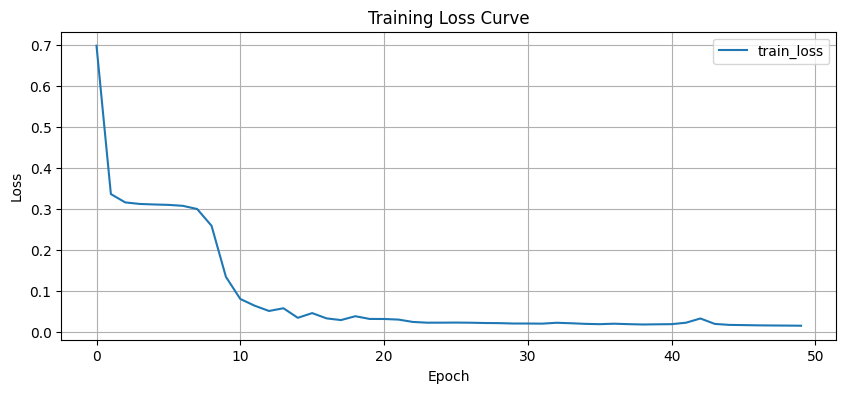


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.000946 | F1=0.2646
p=31.0% | thr=0.000963 | F1=0.2674
p=32.0% | thr=0.000980 | F1=0.2703
p=33.0% | thr=0.001004 | F1=0.2732
p=34.0% | thr=0.001043 | F1=0.2761
p=35.0% | thr=0.001759 | F1=0.2792
p=36.0% | thr=0.002914 | F1=0.2812
p=37.0% | thr=0.003623 | F1=0.2838
p=38.0% | thr=0.004428 | F1=0.2859
p=39.0% | thr=0.005381 | F1=0.2875
p=40.0% | thr=0.009105 | F1=0.2903
p=41.0% | thr=0.009622 | F1=0.2937
p=42.0% | thr=0.009977 | F1=0.2972
p=43.0% | thr=0.010263 | F1=0.3002
p=44.0% | thr=0.010444 | F1=0.3021
p=45.0% | thr=0.010677 | F1=0.3046
p=46.0% | thr=0.010876 | F1=0.3079
p=47.0% | thr=0.011035 | F1=0.3099
p=48.0% | thr=0.011246 | F1=0.3121
p=49.0% | thr=0.011437 | F1=0.3136
p=50.0% | thr=0.011666 | F1=0.3166
p=51.0% | thr=0.011850 | F1=0.3202
p=52.0% | thr=0.012067 | F1=0.3213
p=53.0% | thr=0.012246 | F1=0.3238
p=54.0% | thr=0.012420 | F1=0.3250
p=55.0% | thr=0.012553 | F1=0.3290
p=56.0% | thr=0.012652 | F1=0.3337
p=57.0% | thr=0.012869 | 

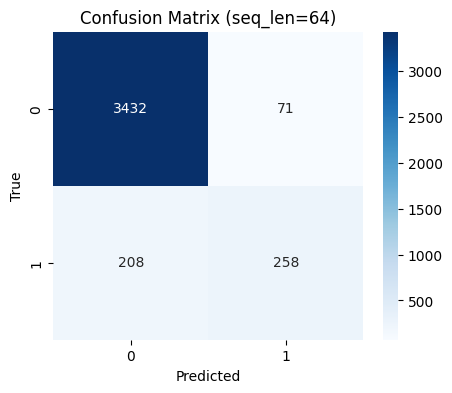


===== ISOLATION FOREST =====
IF -> P=0.5897 R=0.5429 F1=0.5654 ROC_AUC=0.8217 PR_AUC=0.6044


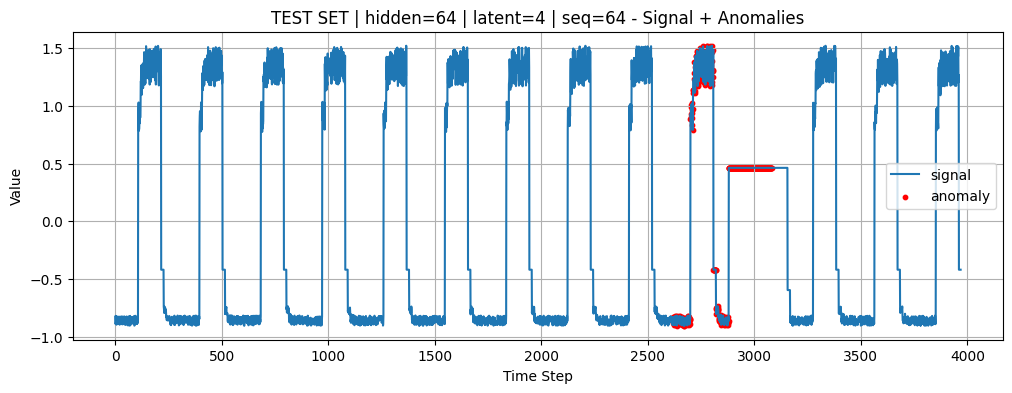

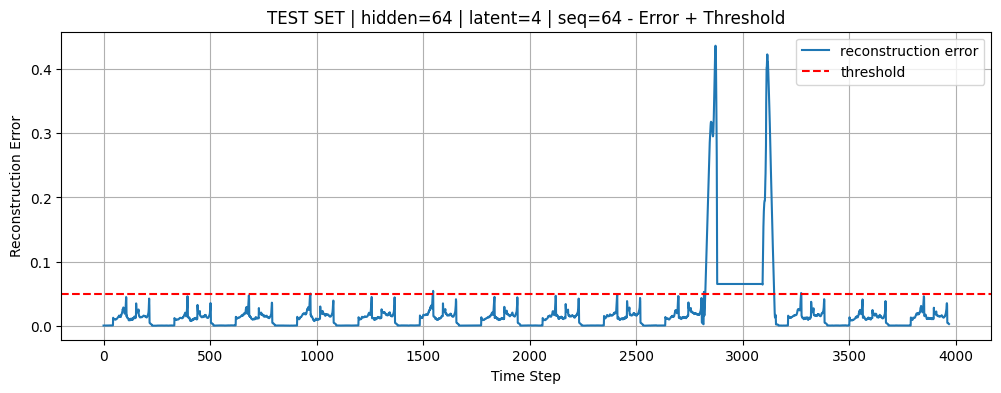


######## RUN 2/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(96)}
Epoch 1 | train_loss=0.89788 | lr=0.0010000
Epoch 2 | train_loss=0.52367 | lr=0.0010000
Epoch 3 | train_loss=0.48625 | lr=0.0010000
Epoch 4 | train_loss=0.46718 | lr=0.0010000
Epoch 5 | train_loss=0.51645 | lr=0.0010000
Epoch 6 | train_loss=0.65005 | lr=0.0010000
Epoch 7 | train_loss=0.51010 | lr=0.0010000
Epoch 8 | train_loss=0.28794 | lr=0.0010000
Epoch 9 | train_loss=0.22975 | lr=0.0010000
Epoch 10 | train_loss=0.15812 | lr=0.0010000
Epoch 11 | train_loss=0.12231 | lr=0.0010000
Epoch 12 | train_loss=0.10477 | lr=0.0010000
Epoch 13 | train_loss=0.10200 | lr=0.0010000
Epoch 14 | train_loss=0.06109 | lr=0.0010000
Epoch 15 | train_loss=0.06009 | lr=0.0010000
Epoch 16 | train_loss=0.06537 | lr=0.0010000
Epoch 17 | train_loss=0.05541 | lr=0.0010000
Epoch 18 | train_loss=0.04961 | lr=0.0010000
Epoch 19 | train_loss=0.05155 | lr=0.0010000
Epoch 20

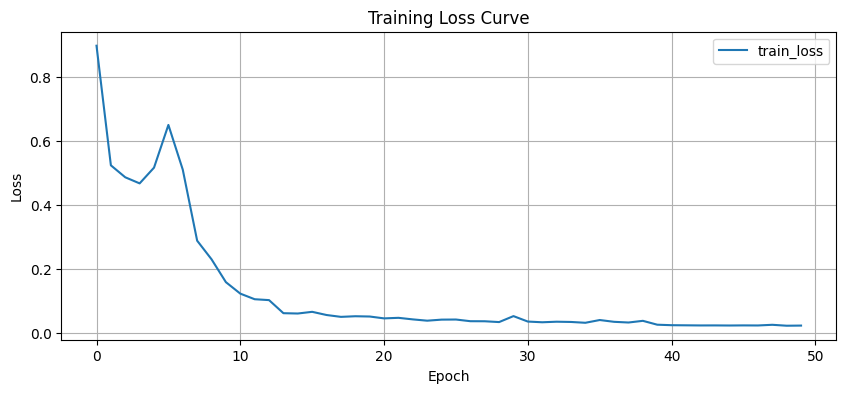


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.014111 | F1=0.2816
p=31.0% | thr=0.014348 | F1=0.2839
p=32.0% | thr=0.014625 | F1=0.2864
p=33.0% | thr=0.014883 | F1=0.2873
p=34.0% | thr=0.015098 | F1=0.2898
p=35.0% | thr=0.015365 | F1=0.2908
p=36.0% | thr=0.015630 | F1=0.2918
p=37.0% | thr=0.015856 | F1=0.2945
p=38.0% | thr=0.016111 | F1=0.2966
p=39.0% | thr=0.016244 | F1=0.2999
p=40.0% | thr=0.016387 | F1=0.3023
p=41.0% | thr=0.016545 | F1=0.3040
p=42.0% | thr=0.016716 | F1=0.3064
p=43.0% | thr=0.016858 | F1=0.3095
p=44.0% | thr=0.017021 | F1=0.3126
p=45.0% | thr=0.017211 | F1=0.3158
p=46.0% | thr=0.017397 | F1=0.3185
p=47.0% | thr=0.017589 | F1=0.3218
p=48.0% | thr=0.017766 | F1=0.3240
p=49.0% | thr=0.017903 | F1=0.3275
p=50.0% | thr=0.018107 | F1=0.3312
p=51.0% | thr=0.018242 | F1=0.3342
p=52.0% | thr=0.018359 | F1=0.3380
p=53.0% | thr=0.018512 | F1=0.3426
p=54.0% | thr=0.018661 | F1=0.3453
p=55.0% | thr=0.018829 | F1=0.3500
p=56.0% | thr=0.018993 | F1=0.3543
p=57.0% | thr=0.019140 | 

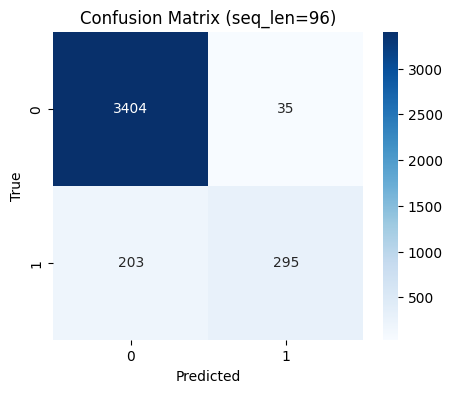


===== ISOLATION FOREST =====
IF -> P=0.6309 R=0.5904 F1=0.6100 ROC_AUC=0.8399 PR_AUC=0.6629


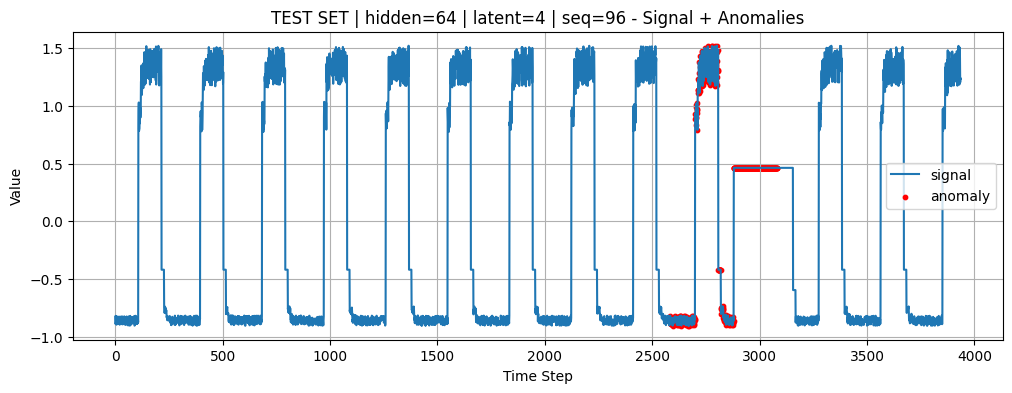

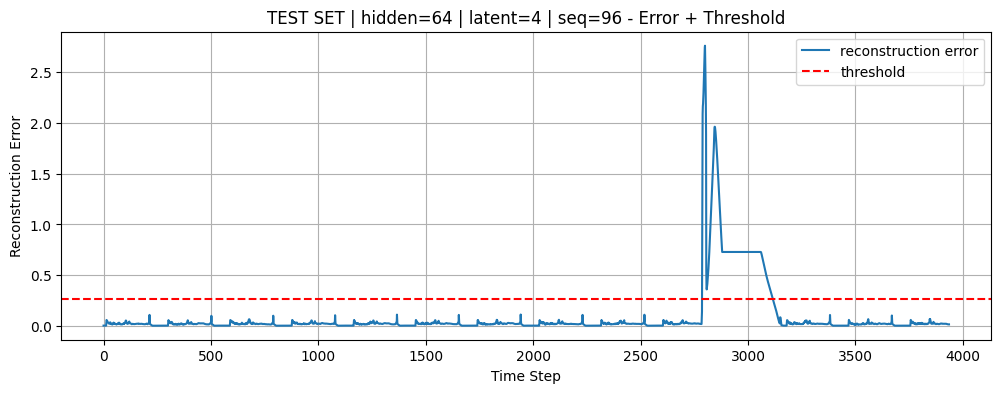


######## RUN 3/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(128)}
Epoch 1 | train_loss=0.98408 | lr=0.0010000
Epoch 2 | train_loss=0.81999 | lr=0.0010000
Epoch 3 | train_loss=0.69335 | lr=0.0010000
Epoch 4 | train_loss=0.65216 | lr=0.0010000
Epoch 5 | train_loss=0.60928 | lr=0.0010000
Epoch 6 | train_loss=0.54846 | lr=0.0010000
Epoch 7 | train_loss=0.44332 | lr=0.0010000
Epoch 8 | train_loss=0.27930 | lr=0.0010000
Epoch 9 | train_loss=0.18455 | lr=0.0010000
Epoch 10 | train_loss=0.12936 | lr=0.0010000
Epoch 11 | train_loss=0.08779 | lr=0.0010000
Epoch 12 | train_loss=0.09204 | lr=0.0010000
Epoch 13 | train_loss=0.06505 | lr=0.0010000
Epoch 14 | train_loss=0.06194 | lr=0.0010000
Epoch 15 | train_loss=0.06188 | lr=0.0010000
Epoch 16 | train_loss=0.05363 | lr=0.0010000
Epoch 17 | train_loss=0.04896 | lr=0.0010000
Epoch 18 | train_loss=0.05132 | lr=0.0010000
Epoch 19 | train_loss=0.05360 | lr=0.0010000
Epoch 2

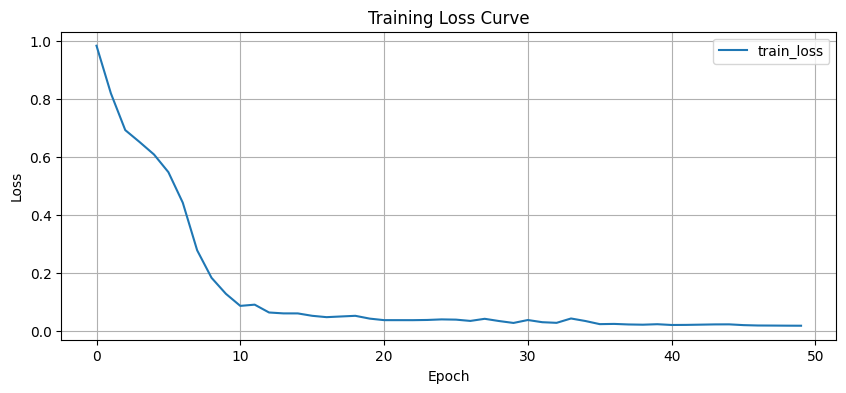


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.013483 | F1=0.2948
p=31.0% | thr=0.013558 | F1=0.2972
p=32.0% | thr=0.013617 | F1=0.2987
p=33.0% | thr=0.013702 | F1=0.3013
p=34.0% | thr=0.013756 | F1=0.3039
p=35.0% | thr=0.013809 | F1=0.3065
p=36.0% | thr=0.013884 | F1=0.3087
p=37.0% | thr=0.013955 | F1=0.3120
p=38.0% | thr=0.014022 | F1=0.3138
p=39.0% | thr=0.014074 | F1=0.3166
p=40.0% | thr=0.014133 | F1=0.3196
p=41.0% | thr=0.014192 | F1=0.3221
p=42.0% | thr=0.014243 | F1=0.3241
p=43.0% | thr=0.014293 | F1=0.3272
p=44.0% | thr=0.014349 | F1=0.3305
p=45.0% | thr=0.014384 | F1=0.3344
p=46.0% | thr=0.014457 | F1=0.3372
p=47.0% | thr=0.014516 | F1=0.3406
p=48.0% | thr=0.014593 | F1=0.3430
p=49.0% | thr=0.014667 | F1=0.3461
p=50.0% | thr=0.014743 | F1=0.3480
p=51.0% | thr=0.014804 | F1=0.3511
p=52.0% | thr=0.014858 | F1=0.3550
p=53.0% | thr=0.014931 | F1=0.3584
p=54.0% | thr=0.015008 | F1=0.3611
p=55.0% | thr=0.015098 | F1=0.3654
p=56.0% | thr=0.015172 | F1=0.3691
p=57.0% | thr=0.015246 | 

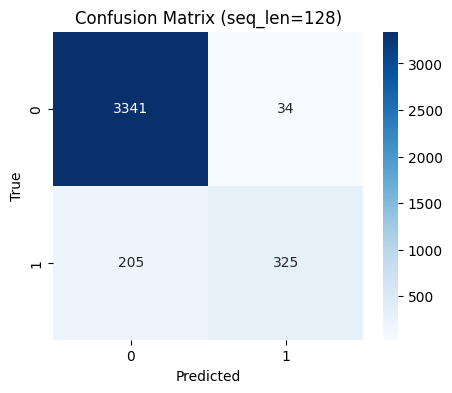


===== ISOLATION FOREST =====
IF -> P=0.6653 R=0.6340 F1=0.6493 ROC_AUC=0.8365 PR_AUC=0.7226


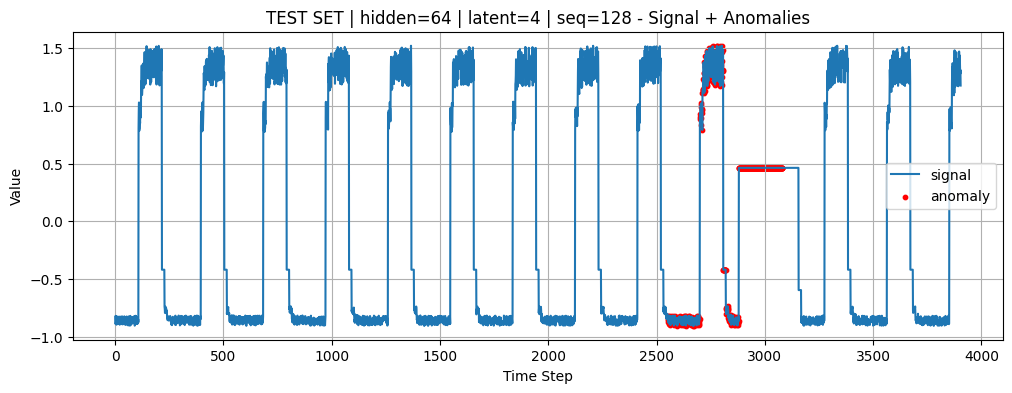

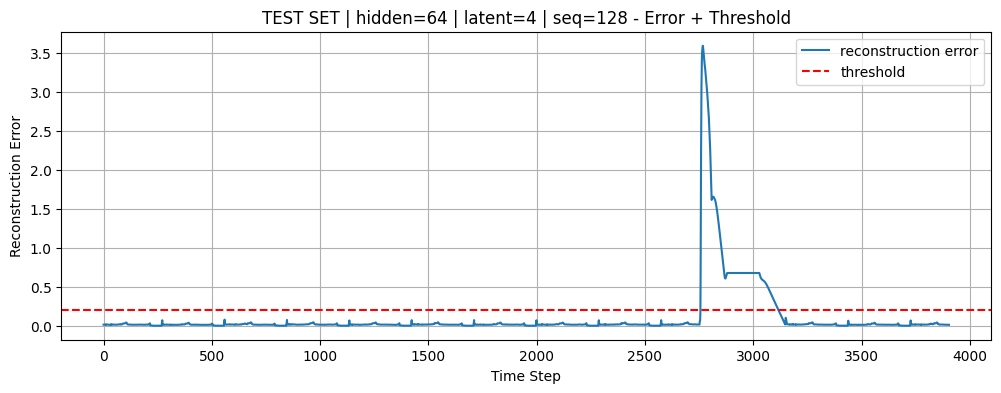


######## RUN 4/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(160)}
Epoch 1 | train_loss=1.06502 | lr=0.0010000
Epoch 2 | train_loss=1.06115 | lr=0.0010000
Epoch 3 | train_loss=1.06102 | lr=0.0010000
Epoch 4 | train_loss=1.05508 | lr=0.0010000
Epoch 5 | train_loss=1.05598 | lr=0.0010000
Epoch 6 | train_loss=1.05689 | lr=0.0010000
Epoch 7 | train_loss=1.00348 | lr=0.0010000
Epoch 8 | train_loss=0.75203 | lr=0.0010000
Epoch 9 | train_loss=0.59243 | lr=0.0010000
Epoch 10 | train_loss=0.49719 | lr=0.0010000
Epoch 11 | train_loss=0.40669 | lr=0.0010000
Epoch 12 | train_loss=0.29988 | lr=0.0010000
Epoch 13 | train_loss=0.79699 | lr=0.0010000
Epoch 14 | train_loss=1.01447 | lr=0.0010000
Epoch 15 | train_loss=0.89580 | lr=0.0010000
Epoch 16 | train_loss=0.80647 | lr=0.0005000
Epoch 17 | train_loss=0.57865 | lr=0.0005000
Epoch 18 | train_loss=0.38232 | lr=0.0005000
Epoch 19 | train_loss=0.30896 | lr=0.0005000
Epoch 2

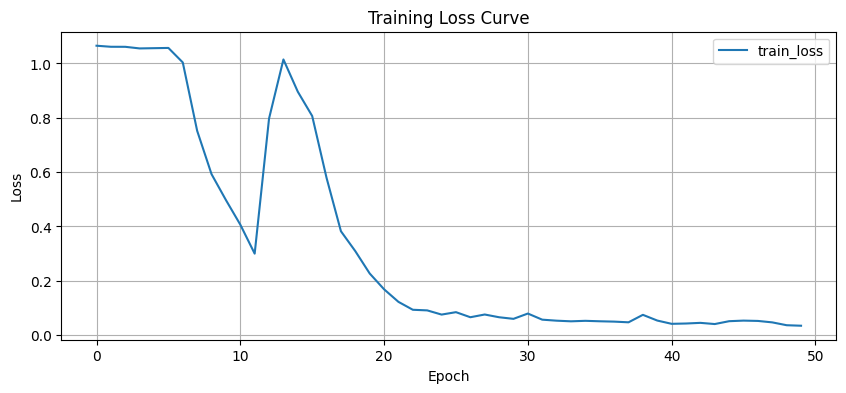


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.020431 | F1=0.2853
p=31.0% | thr=0.020729 | F1=0.2876
p=32.0% | thr=0.021047 | F1=0.2905
p=33.0% | thr=0.021360 | F1=0.2929
p=34.0% | thr=0.021677 | F1=0.2959
p=35.0% | thr=0.021913 | F1=0.2984
p=36.0% | thr=0.022182 | F1=0.3010
p=37.0% | thr=0.022420 | F1=0.3037
p=38.0% | thr=0.022694 | F1=0.3069
p=39.0% | thr=0.022995 | F1=0.3102
p=40.0% | thr=0.023277 | F1=0.3126
p=41.0% | thr=0.023493 | F1=0.3160
p=42.0% | thr=0.023774 | F1=0.3196
p=43.0% | thr=0.024047 | F1=0.3220
p=44.0% | thr=0.024323 | F1=0.3251
p=45.0% | thr=0.024595 | F1=0.3289
p=46.0% | thr=0.024868 | F1=0.3327
p=47.0% | thr=0.025085 | F1=0.3361
p=48.0% | thr=0.025261 | F1=0.3401
p=49.0% | thr=0.025574 | F1=0.3442
p=50.0% | thr=0.025814 | F1=0.3486
p=51.0% | thr=0.026073 | F1=0.3529
p=52.0% | thr=0.026272 | F1=0.3568
p=53.0% | thr=0.026501 | F1=0.3613
p=54.0% | thr=0.026893 | F1=0.3660
p=55.0% | thr=0.027091 | F1=0.3701
p=56.0% | thr=0.027458 | F1=0.3751
p=57.0% | thr=0.027751 | 

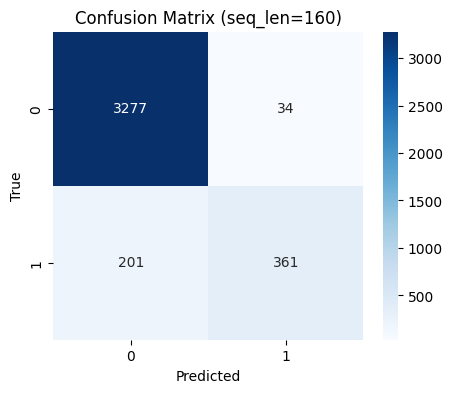


===== ISOLATION FOREST =====
IF -> P=0.6880 R=0.6512 F1=0.6691 ROC_AUC=0.8289 PR_AUC=0.7435


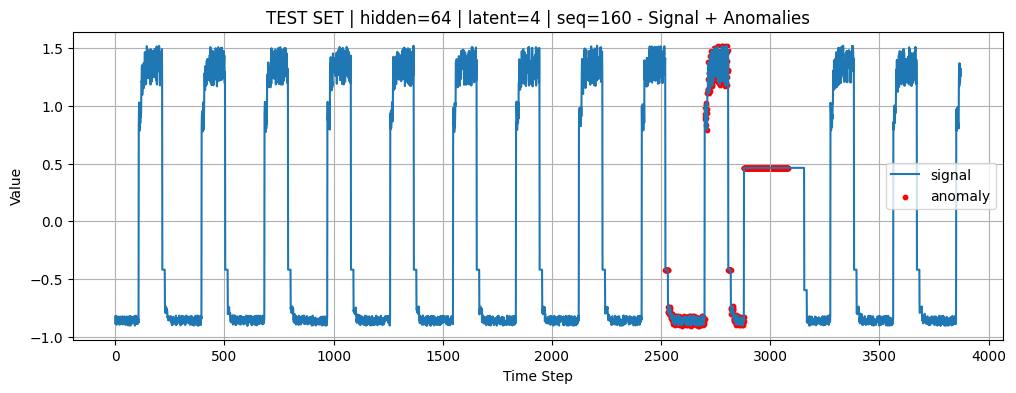

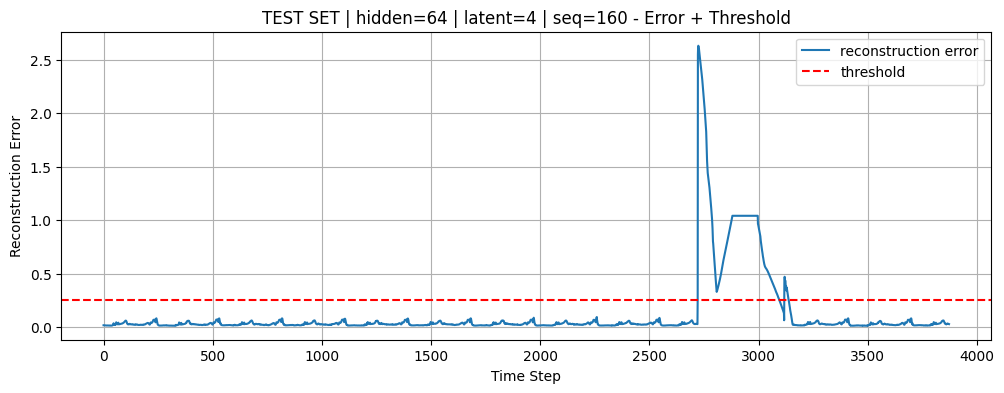


######## RUN 5/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(192)}
Epoch 1 | train_loss=1.04798 | lr=0.0010000
Epoch 2 | train_loss=1.03164 | lr=0.0010000
Epoch 3 | train_loss=1.03617 | lr=0.0010000
Epoch 4 | train_loss=1.01681 | lr=0.0010000
Epoch 5 | train_loss=1.01027 | lr=0.0010000
Epoch 6 | train_loss=1.00679 | lr=0.0010000
Epoch 7 | train_loss=1.00433 | lr=0.0010000
Epoch 8 | train_loss=1.00266 | lr=0.0010000
Epoch 9 | train_loss=0.99970 | lr=0.0010000
Epoch 10 | train_loss=1.01666 | lr=0.0010000
Epoch 11 | train_loss=1.04308 | lr=0.0010000
Epoch 12 | train_loss=1.00083 | lr=0.0010000
Epoch 13 | train_loss=1.02435 | lr=0.0005000
Epoch 14 | train_loss=0.99844 | lr=0.0005000
Epoch 15 | train_loss=0.92142 | lr=0.0005000
Epoch 16 | train_loss=0.81107 | lr=0.0005000
Epoch 17 | train_loss=0.76744 | lr=0.0005000
Epoch 18 | train_loss=0.71556 | lr=0.0005000
Epoch 19 | train_loss=0.66678 | lr=0.0005000
Epoch 2

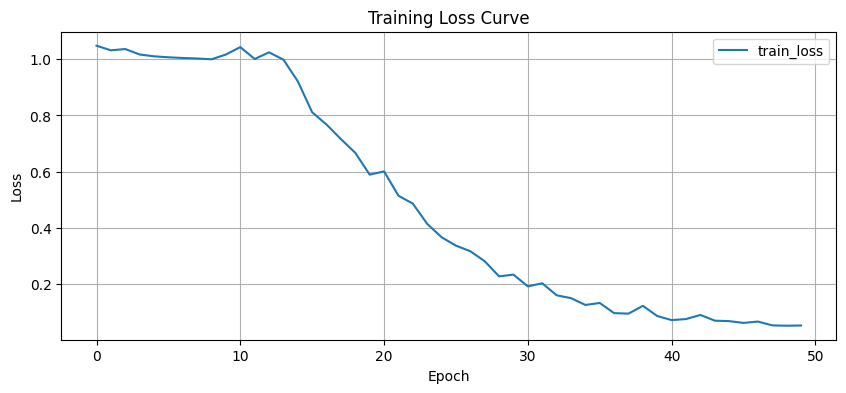


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.030840 | F1=0.3051
p=31.0% | thr=0.031420 | F1=0.3081
p=32.0% | thr=0.032383 | F1=0.3090
p=33.0% | thr=0.033258 | F1=0.3111
p=34.0% | thr=0.034002 | F1=0.3136
p=35.0% | thr=0.034658 | F1=0.3163
p=36.0% | thr=0.035258 | F1=0.3190
p=37.0% | thr=0.035959 | F1=0.3218
p=38.0% | thr=0.036583 | F1=0.3240
p=39.0% | thr=0.037185 | F1=0.3268
p=40.0% | thr=0.037930 | F1=0.3293
p=41.0% | thr=0.038340 | F1=0.3322
p=42.0% | thr=0.039016 | F1=0.3359
p=43.0% | thr=0.039708 | F1=0.3379
p=44.0% | thr=0.040175 | F1=0.3417
p=45.0% | thr=0.040826 | F1=0.3449
p=46.0% | thr=0.041397 | F1=0.3460
p=47.0% | thr=0.042018 | F1=0.3500
p=48.0% | thr=0.042635 | F1=0.3541
p=49.0% | thr=0.043351 | F1=0.3583
p=50.0% | thr=0.043971 | F1=0.3626
p=51.0% | thr=0.044434 | F1=0.3664
p=52.0% | thr=0.044893 | F1=0.3708
p=53.0% | thr=0.045515 | F1=0.3730
p=54.0% | thr=0.046263 | F1=0.3776
p=55.0% | thr=0.046750 | F1=0.3825
p=56.0% | thr=0.047125 | F1=0.3874
p=57.0% | thr=0.047482 | 

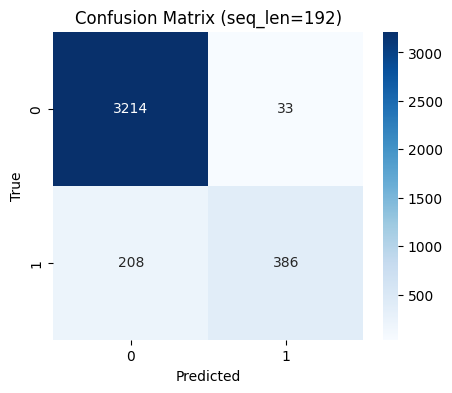


===== ISOLATION FOREST =====
IF -> P=0.7135 R=0.6835 F1=0.6982 ROC_AUC=0.8288 PR_AUC=0.7542


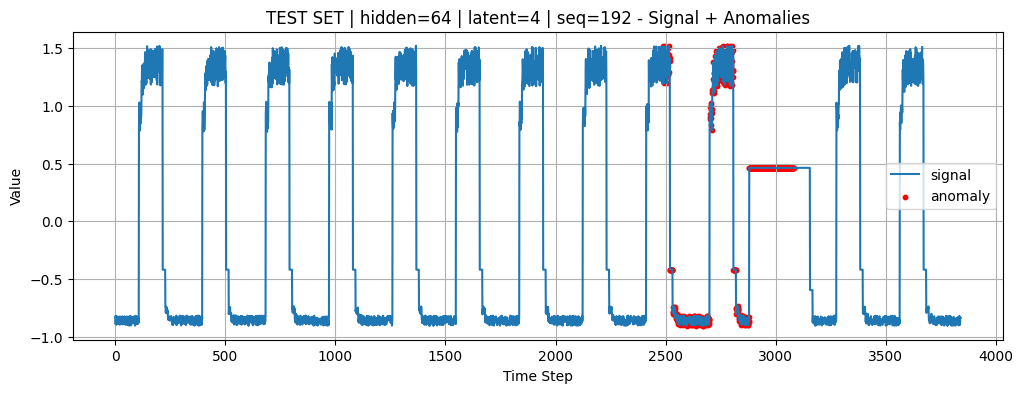

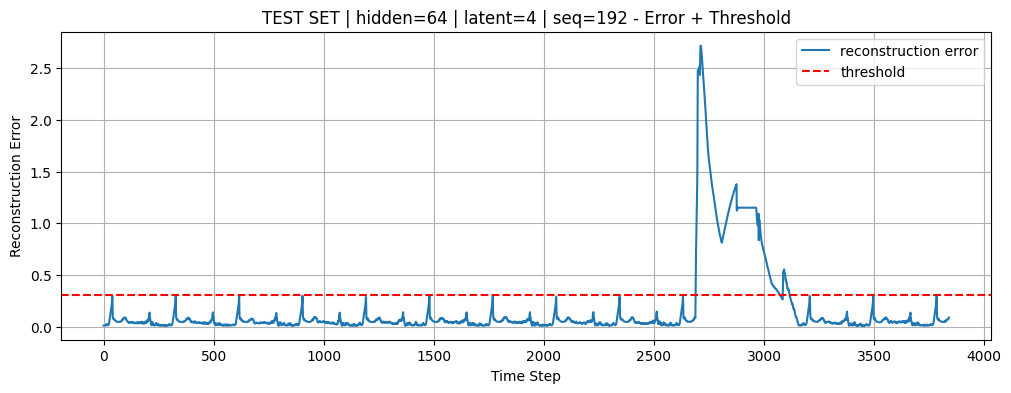


######## RUN 6/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(224)}
Epoch 1 | train_loss=1.04368 | lr=0.0010000
Epoch 2 | train_loss=1.03809 | lr=0.0010000
Epoch 3 | train_loss=1.03281 | lr=0.0010000
Epoch 4 | train_loss=1.02162 | lr=0.0010000
Epoch 5 | train_loss=1.01943 | lr=0.0010000
Epoch 6 | train_loss=1.00924 | lr=0.0010000
Epoch 7 | train_loss=1.05779 | lr=0.0010000
Epoch 8 | train_loss=1.04631 | lr=0.0010000
Epoch 9 | train_loss=1.03784 | lr=0.0010000
Epoch 10 | train_loss=1.03434 | lr=0.0005000
Epoch 11 | train_loss=1.03198 | lr=0.0005000
Epoch 12 | train_loss=1.02339 | lr=0.0005000
Epoch 13 | train_loss=1.01596 | lr=0.0005000
Epoch 14 | train_loss=0.99585 | lr=0.0005000
Epoch 15 | train_loss=0.96025 | lr=0.0005000
Epoch 16 | train_loss=0.88418 | lr=0.0005000
Epoch 17 | train_loss=0.95487 | lr=0.0005000
Epoch 18 | train_loss=0.83534 | lr=0.0005000
Epoch 19 | train_loss=0.76864 | lr=0.0005000
Epoch 2

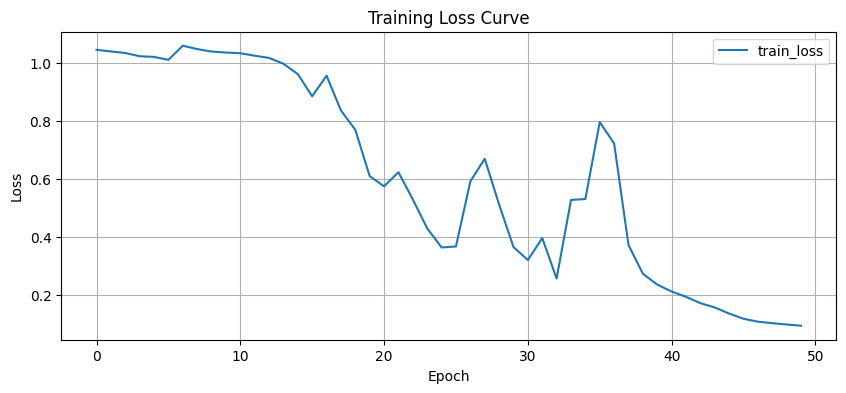


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.065575 | F1=0.3295
p=31.0% | thr=0.065987 | F1=0.3317
p=32.0% | thr=0.066288 | F1=0.3343
p=33.0% | thr=0.066739 | F1=0.3360
p=34.0% | thr=0.067161 | F1=0.3372
p=35.0% | thr=0.067439 | F1=0.3405
p=36.0% | thr=0.067822 | F1=0.3439
p=37.0% | thr=0.068257 | F1=0.3458
p=38.0% | thr=0.068891 | F1=0.3488
p=39.0% | thr=0.069400 | F1=0.3517
p=40.0% | thr=0.069776 | F1=0.3554
p=41.0% | thr=0.070218 | F1=0.3591
p=42.0% | thr=0.070691 | F1=0.3629
p=43.0% | thr=0.071049 | F1=0.3668
p=44.0% | thr=0.071446 | F1=0.3702
p=45.0% | thr=0.071874 | F1=0.3730
p=46.0% | thr=0.072272 | F1=0.3766
p=47.0% | thr=0.072894 | F1=0.3808
p=48.0% | thr=0.073423 | F1=0.3846
p=49.0% | thr=0.073946 | F1=0.3878
p=50.0% | thr=0.074554 | F1=0.3917
p=51.0% | thr=0.075209 | F1=0.3944
p=52.0% | thr=0.075814 | F1=0.3991
p=53.0% | thr=0.076476 | F1=0.4039
p=54.0% | thr=0.077522 | F1=0.4082
p=55.0% | thr=0.078135 | F1=0.4133
p=56.0% | thr=0.079293 | F1=0.4164
p=57.0% | thr=0.080162 | 

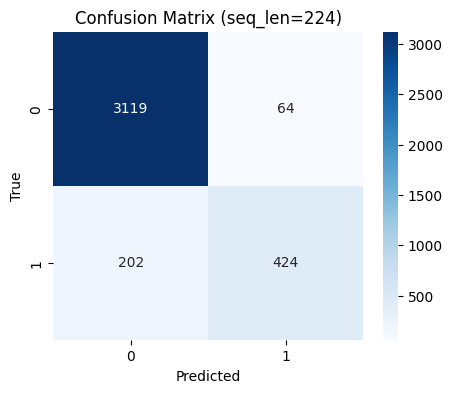


===== ISOLATION FOREST =====
IF -> P=0.7256 R=0.6757 F1=0.6998 ROC_AUC=0.8204 PR_AUC=0.7492


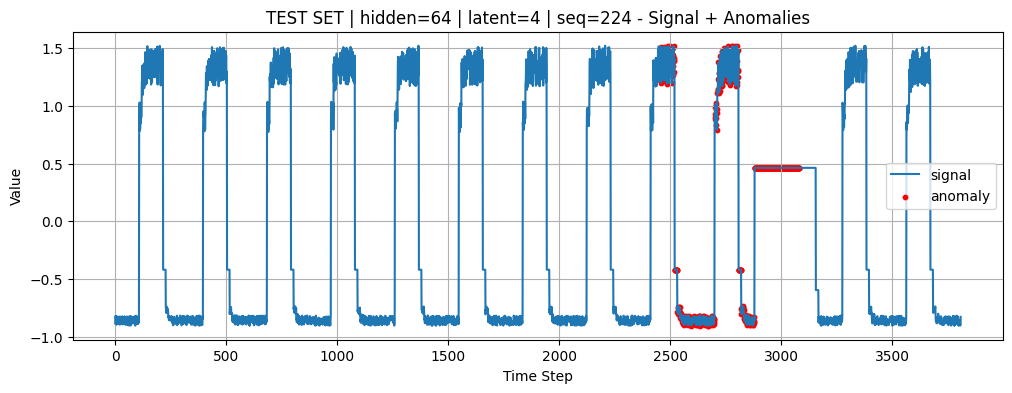

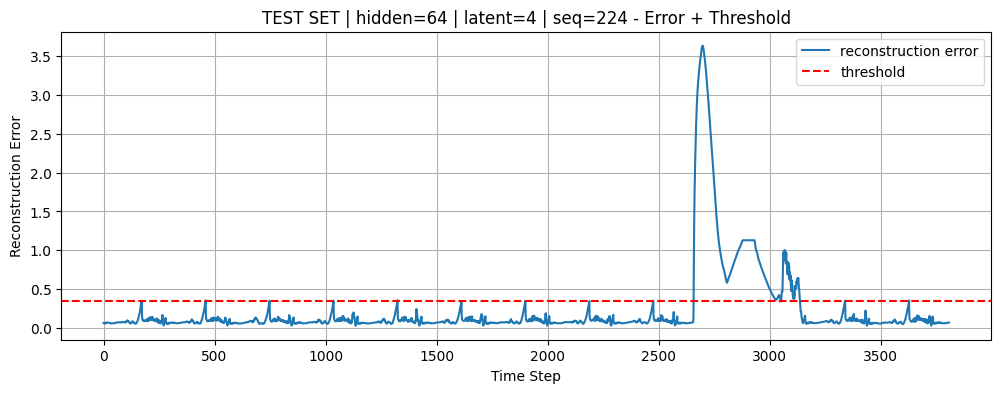


######## RUN 7/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(256)}
Epoch 1 | train_loss=1.05327 | lr=0.0010000
Epoch 2 | train_loss=1.04718 | lr=0.0010000
Epoch 3 | train_loss=1.04258 | lr=0.0010000
Epoch 4 | train_loss=1.03486 | lr=0.0010000
Epoch 5 | train_loss=1.02916 | lr=0.0010000
Epoch 6 | train_loss=1.02778 | lr=0.0010000
Epoch 7 | train_loss=1.02443 | lr=0.0010000
Epoch 8 | train_loss=1.02915 | lr=0.0010000
Epoch 9 | train_loss=1.03116 | lr=0.0010000
Epoch 10 | train_loss=1.02399 | lr=0.0010000
Epoch 11 | train_loss=1.02510 | lr=0.0010000
Epoch 12 | train_loss=1.02235 | lr=0.0010000
Epoch 13 | train_loss=1.01758 | lr=0.0010000
Epoch 14 | train_loss=1.01277 | lr=0.0010000
Epoch 15 | train_loss=0.99990 | lr=0.0010000
Epoch 16 | train_loss=1.00051 | lr=0.0010000
Epoch 17 | train_loss=1.02737 | lr=0.0010000
Epoch 18 | train_loss=1.05616 | lr=0.0010000
Epoch 19 | train_loss=1.04794 | lr=0.0005000
Epoch 2

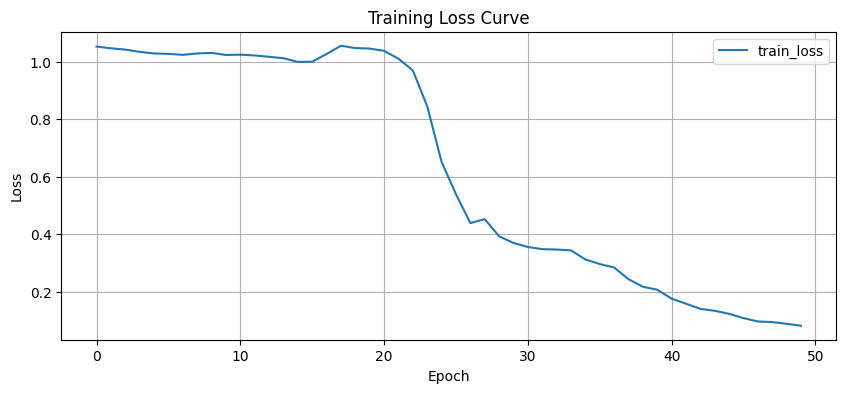


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.046103 | F1=0.3583
p=31.0% | thr=0.046476 | F1=0.3615
p=32.0% | thr=0.046787 | F1=0.3634
p=33.0% | thr=0.047039 | F1=0.3667
p=34.0% | thr=0.047416 | F1=0.3693
p=35.0% | thr=0.047783 | F1=0.3722
p=36.0% | thr=0.048065 | F1=0.3753
p=37.0% | thr=0.048337 | F1=0.3789
p=38.0% | thr=0.048705 | F1=0.3820
p=39.0% | thr=0.049039 | F1=0.3854
p=40.0% | thr=0.049485 | F1=0.3887
p=41.0% | thr=0.049819 | F1=0.3915
p=42.0% | thr=0.050127 | F1=0.3934
p=43.0% | thr=0.050586 | F1=0.3958
p=44.0% | thr=0.051018 | F1=0.3972
p=45.0% | thr=0.051371 | F1=0.3993
p=46.0% | thr=0.051848 | F1=0.4003
p=47.0% | thr=0.052312 | F1=0.4040
p=48.0% | thr=0.052692 | F1=0.4073
p=49.0% | thr=0.053100 | F1=0.4106
p=50.0% | thr=0.053523 | F1=0.4142
p=51.0% | thr=0.054180 | F1=0.4165
p=52.0% | thr=0.054773 | F1=0.4195
p=53.0% | thr=0.055441 | F1=0.4214
p=54.0% | thr=0.056325 | F1=0.4257
p=55.0% | thr=0.057301 | F1=0.4296
p=56.0% | thr=0.058715 | F1=0.4348
p=57.0% | thr=0.060064 | 

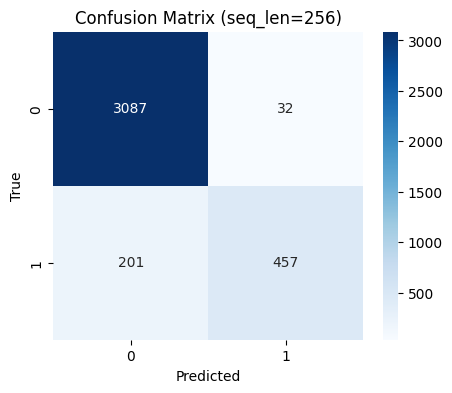


===== ISOLATION FOREST =====
IF -> P=0.7443 R=0.6900 F1=0.7161 ROC_AUC=0.8142 PR_AUC=0.7534


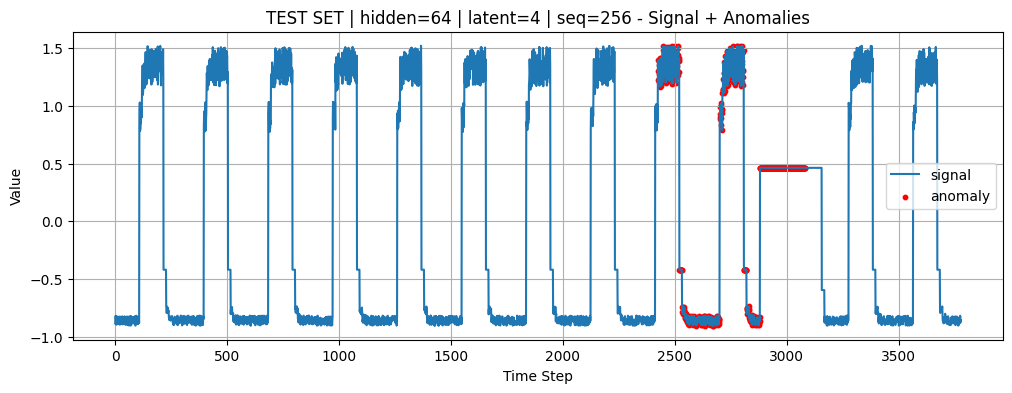

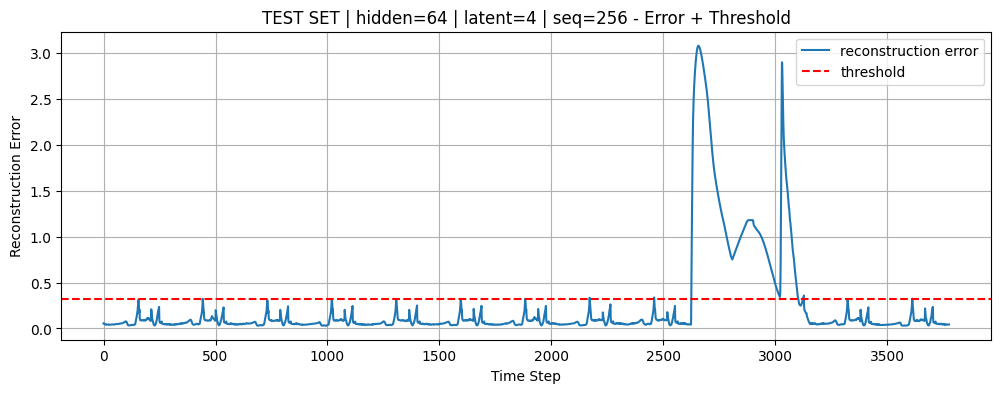


######## RUN 8/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(288)}
Epoch 1 | train_loss=1.05721 | lr=0.0010000
Epoch 2 | train_loss=1.04552 | lr=0.0010000
Epoch 3 | train_loss=1.02027 | lr=0.0010000
Epoch 4 | train_loss=0.99822 | lr=0.0010000
Epoch 5 | train_loss=0.97894 | lr=0.0010000
Epoch 6 | train_loss=0.95028 | lr=0.0010000
Epoch 7 | train_loss=0.90600 | lr=0.0010000
Epoch 8 | train_loss=0.90855 | lr=0.0010000
Epoch 9 | train_loss=0.89296 | lr=0.0010000
Epoch 10 | train_loss=0.87294 | lr=0.0010000
Epoch 11 | train_loss=0.82205 | lr=0.0010000
Epoch 12 | train_loss=0.77509 | lr=0.0010000
Epoch 13 | train_loss=0.68607 | lr=0.0010000
Epoch 14 | train_loss=0.74751 | lr=0.0010000
Epoch 15 | train_loss=0.66037 | lr=0.0010000
Epoch 16 | train_loss=0.64128 | lr=0.0010000
Epoch 17 | train_loss=0.68420 | lr=0.0010000
Epoch 18 | train_loss=0.52647 | lr=0.0010000
Epoch 19 | train_loss=0.55145 | lr=0.0010000
Epoch 2

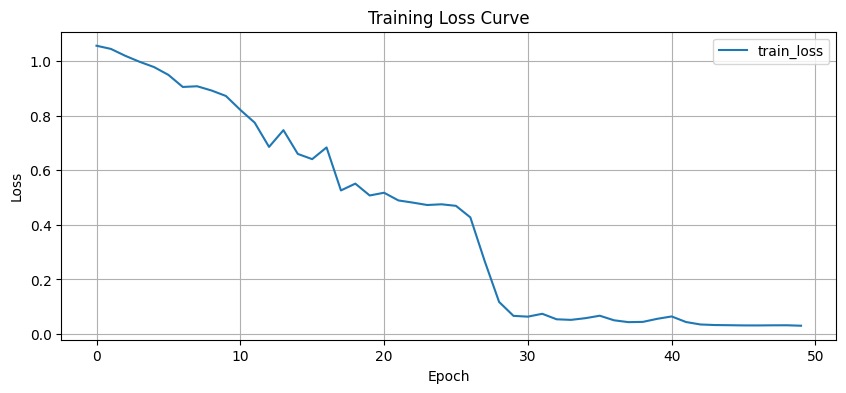


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.022897 | F1=0.3747
p=31.0% | thr=0.022966 | F1=0.3775
p=32.0% | thr=0.023041 | F1=0.3805
p=33.0% | thr=0.023176 | F1=0.3833
p=34.0% | thr=0.023248 | F1=0.3864
p=35.0% | thr=0.023339 | F1=0.3894
p=36.0% | thr=0.023464 | F1=0.3921
p=37.0% | thr=0.023531 | F1=0.3947
p=38.0% | thr=0.023626 | F1=0.3965
p=39.0% | thr=0.023784 | F1=0.3984
p=40.0% | thr=0.023896 | F1=0.4006
p=41.0% | thr=0.024025 | F1=0.4036
p=42.0% | thr=0.024135 | F1=0.4054
p=43.0% | thr=0.024213 | F1=0.4090
p=44.0% | thr=0.024312 | F1=0.4099
p=45.0% | thr=0.024402 | F1=0.4110
p=46.0% | thr=0.024540 | F1=0.4125
p=47.0% | thr=0.024644 | F1=0.4152
p=48.0% | thr=0.024747 | F1=0.4174
p=49.0% | thr=0.024856 | F1=0.4202
p=50.0% | thr=0.024964 | F1=0.4232
p=51.0% | thr=0.025081 | F1=0.4261
p=52.0% | thr=0.025201 | F1=0.4291
p=53.0% | thr=0.025339 | F1=0.4310
p=54.0% | thr=0.025511 | F1=0.4325
p=55.0% | thr=0.025649 | F1=0.4362
p=56.0% | thr=0.025772 | F1=0.4396
p=57.0% | thr=0.025917 | 

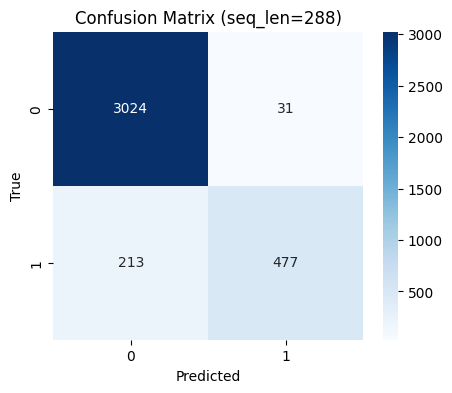


===== ISOLATION FOREST =====
IF -> P=0.7579 R=0.6942 F1=0.7247 ROC_AUC=0.8407 PR_AUC=0.7799


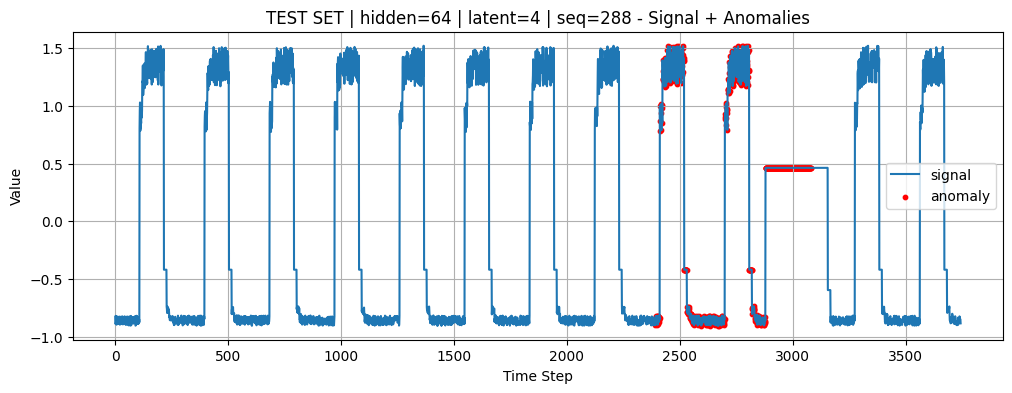

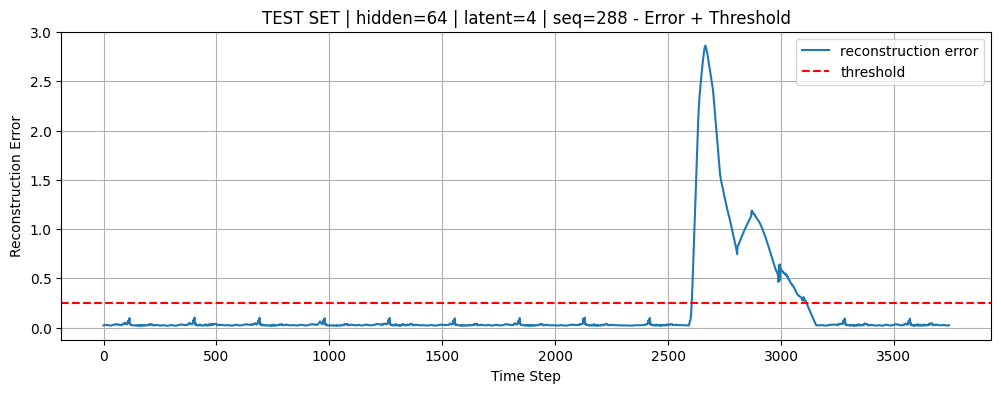


######## RUN 9/18 ########

================ RUN =================
{'hidden_dim': 64, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(320)}
Epoch 1 | train_loss=1.05068 | lr=0.0010000
Epoch 2 | train_loss=1.04144 | lr=0.0010000
Epoch 3 | train_loss=1.02937 | lr=0.0010000
Epoch 4 | train_loss=1.03116 | lr=0.0010000
Epoch 5 | train_loss=1.00727 | lr=0.0010000
Epoch 6 | train_loss=0.96451 | lr=0.0010000
Epoch 7 | train_loss=0.91607 | lr=0.0010000
Epoch 8 | train_loss=0.91512 | lr=0.0010000
Epoch 9 | train_loss=0.91188 | lr=0.0010000
Epoch 10 | train_loss=0.90067 | lr=0.0010000
Epoch 11 | train_loss=0.89218 | lr=0.0010000
Epoch 12 | train_loss=0.88734 | lr=0.0010000
Epoch 13 | train_loss=0.88531 | lr=0.0010000
Epoch 14 | train_loss=0.86253 | lr=0.0010000
Epoch 15 | train_loss=0.83745 | lr=0.0010000
Epoch 16 | train_loss=0.82241 | lr=0.0010000
Epoch 17 | train_loss=0.82582 | lr=0.0010000
Epoch 18 | train_loss=0.81182 | lr=0.0010000
Epoch 19 | train_loss=0.80909 | lr=0.0010000
Epoch 2

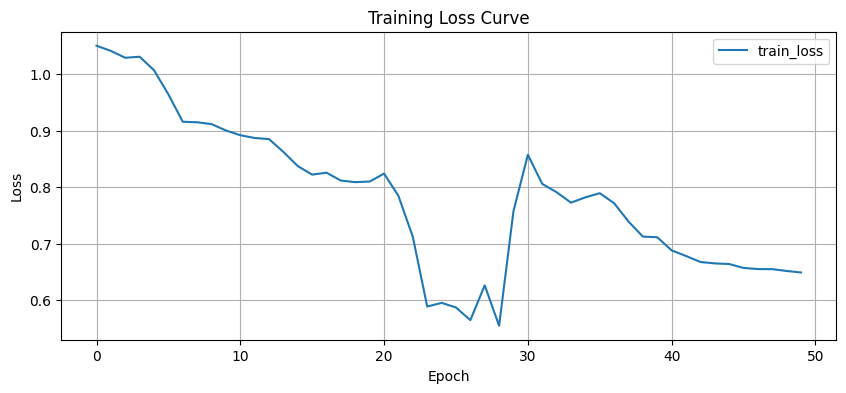


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.452295 | F1=0.3289
p=31.0% | thr=0.464342 | F1=0.3297
p=32.0% | thr=0.474302 | F1=0.3297
p=33.0% | thr=0.486288 | F1=0.3312
p=34.0% | thr=0.496692 | F1=0.3312
p=35.0% | thr=0.505157 | F1=0.3317
p=36.0% | thr=0.514139 | F1=0.3327
p=37.0% | thr=0.523926 | F1=0.3332
p=38.0% | thr=0.532640 | F1=0.3332
p=39.0% | thr=0.539556 | F1=0.3349
p=40.0% | thr=0.547685 | F1=0.3343
p=41.0% | thr=0.556351 | F1=0.3348
p=42.0% | thr=0.564768 | F1=0.3354
p=43.0% | thr=0.574700 | F1=0.3365
p=44.0% | thr=0.585353 | F1=0.3377
p=45.0% | thr=0.593392 | F1=0.3384
p=46.0% | thr=0.603903 | F1=0.3402
p=47.0% | thr=0.611929 | F1=0.3409
p=48.0% | thr=0.621708 | F1=0.3422
p=49.0% | thr=0.632100 | F1=0.3435
p=50.0% | thr=0.642179 | F1=0.3461
p=51.0% | thr=0.652468 | F1=0.3493
p=52.0% | thr=0.661694 | F1=0.3533
p=53.0% | thr=0.672310 | F1=0.3568
p=54.0% | thr=0.682092 | F1=0.3597
p=55.0% | thr=0.692408 | F1=0.3639
p=56.0% | thr=0.700729 | F1=0.3670
p=57.0% | thr=0.708566 | 

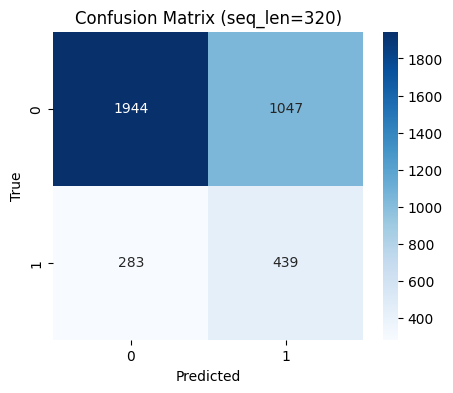


===== ISOLATION FOREST =====
IF -> P=0.7713 R=0.7008 F1=0.7344 ROC_AUC=0.8623 PR_AUC=0.7821


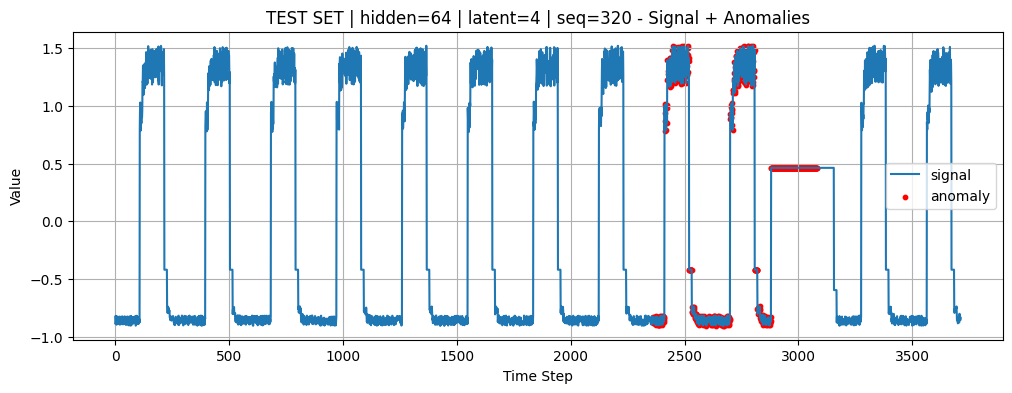

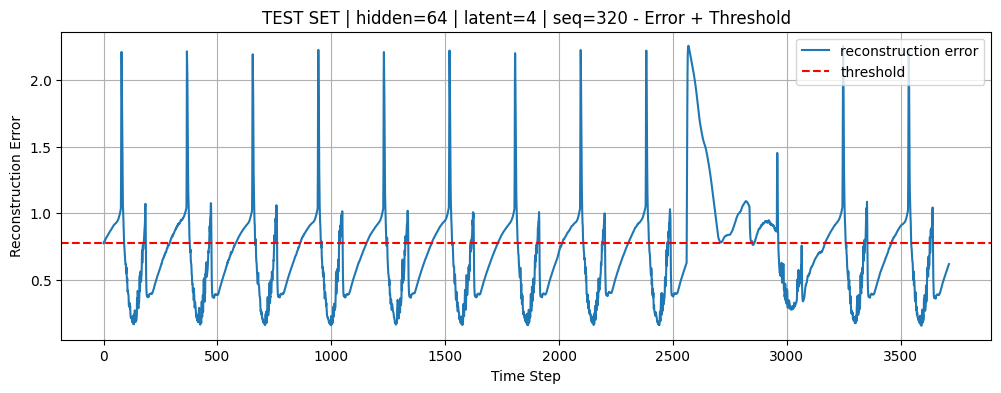


######## RUN 10/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(64)}
Epoch 1 | train_loss=0.56241 | lr=0.0010000
Epoch 2 | train_loss=0.31143 | lr=0.0010000
Epoch 3 | train_loss=0.30025 | lr=0.0010000
Epoch 4 | train_loss=0.29551 | lr=0.0010000
Epoch 5 | train_loss=0.29591 | lr=0.0010000
Epoch 6 | train_loss=0.20887 | lr=0.0010000
Epoch 7 | train_loss=0.10554 | lr=0.0010000
Epoch 8 | train_loss=0.09171 | lr=0.0010000
Epoch 9 | train_loss=0.07307 | lr=0.0010000
Epoch 10 | train_loss=0.06073 | lr=0.0010000
Epoch 11 | train_loss=0.05443 | lr=0.0010000
Epoch 12 | train_loss=0.05317 | lr=0.0010000
Epoch 13 | train_loss=0.04562 | lr=0.0010000
Epoch 14 | train_loss=0.07867 | lr=0.0010000
Epoch 15 | train_loss=0.07145 | lr=0.0010000
Epoch 16 | train_loss=0.05279 | lr=0.0010000
Epoch 17 | train_loss=0.04694 | lr=0.0005000
Epoch 18 | train_loss=0.03834 | lr=0.0005000
Epoch 19 | train_loss=0.03001 | lr=0.0005000
Epoch 

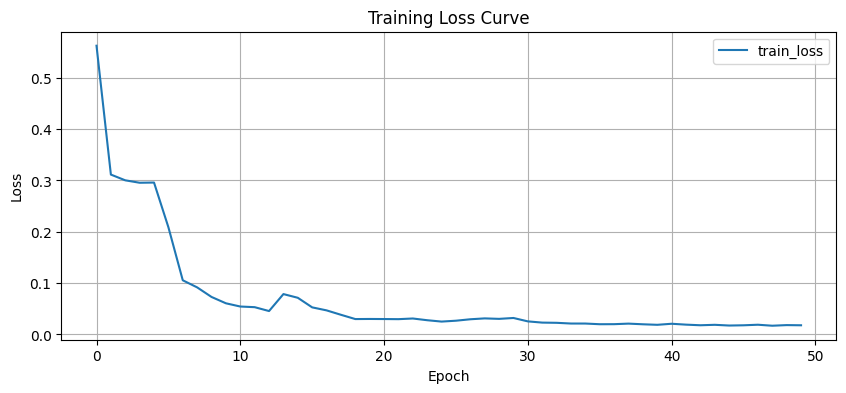


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.001302 | F1=0.2646
p=31.0% | thr=0.001322 | F1=0.2674
p=32.0% | thr=0.001346 | F1=0.2703
p=33.0% | thr=0.001377 | F1=0.2732
p=34.0% | thr=0.001426 | F1=0.2761
p=35.0% | thr=0.002171 | F1=0.2792
p=36.0% | thr=0.007409 | F1=0.2823
p=37.0% | thr=0.008817 | F1=0.2854
p=38.0% | thr=0.009279 | F1=0.2876
p=39.0% | thr=0.009704 | F1=0.2903
p=40.0% | thr=0.009971 | F1=0.2937
p=41.0% | thr=0.010242 | F1=0.2960
p=42.0% | thr=0.010517 | F1=0.2995
p=43.0% | thr=0.010761 | F1=0.3025
p=44.0% | thr=0.010959 | F1=0.3045
p=45.0% | thr=0.011143 | F1=0.3076
p=46.0% | thr=0.011332 | F1=0.3103
p=47.0% | thr=0.011487 | F1=0.3124
p=48.0% | thr=0.011719 | F1=0.3139
p=49.0% | thr=0.011895 | F1=0.3168
p=50.0% | thr=0.012089 | F1=0.3179
p=51.0% | thr=0.012278 | F1=0.3209
p=52.0% | thr=0.012448 | F1=0.3227
p=53.0% | thr=0.012674 | F1=0.3238
p=54.0% | thr=0.012891 | F1=0.3243
p=55.0% | thr=0.013059 | F1=0.3276
p=56.0% | thr=0.013331 | F1=0.3296
p=57.0% | thr=0.013721 | 

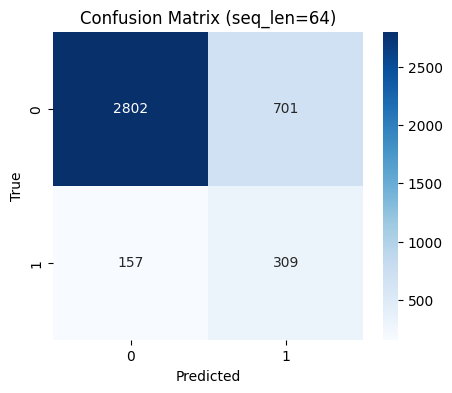


===== ISOLATION FOREST =====
IF -> P=0.5897 R=0.5429 F1=0.5654 ROC_AUC=0.8163 PR_AUC=0.5706


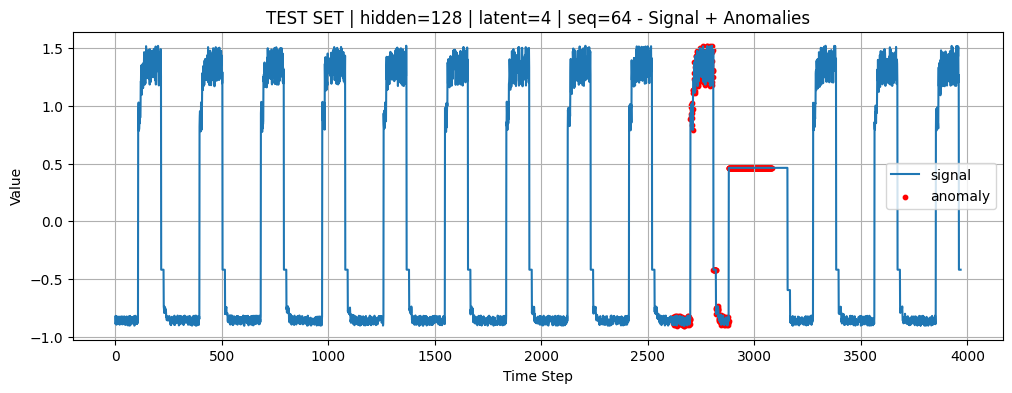

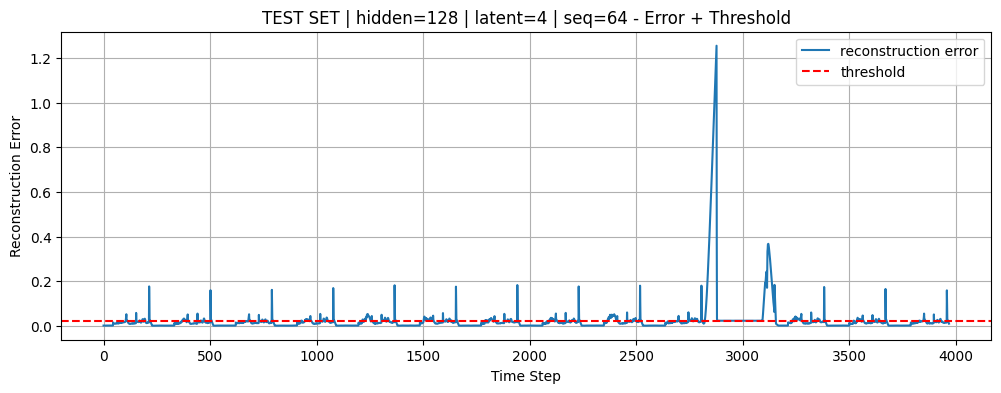


######## RUN 11/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(96)}
Epoch 1 | train_loss=0.76394 | lr=0.0010000
Epoch 2 | train_loss=0.50196 | lr=0.0010000
Epoch 3 | train_loss=0.47739 | lr=0.0010000
Epoch 4 | train_loss=0.47156 | lr=0.0010000
Epoch 5 | train_loss=0.44810 | lr=0.0010000
Epoch 6 | train_loss=0.41579 | lr=0.0010000
Epoch 7 | train_loss=0.19168 | lr=0.0010000
Epoch 8 | train_loss=0.10931 | lr=0.0010000
Epoch 9 | train_loss=0.08573 | lr=0.0010000
Epoch 10 | train_loss=0.05599 | lr=0.0010000
Epoch 11 | train_loss=0.05383 | lr=0.0010000
Epoch 12 | train_loss=0.04179 | lr=0.0010000
Epoch 13 | train_loss=0.04574 | lr=0.0010000
Epoch 14 | train_loss=0.07654 | lr=0.0010000
Epoch 15 | train_loss=0.04855 | lr=0.0010000
Epoch 16 | train_loss=0.03749 | lr=0.0010000
Epoch 17 | train_loss=0.04421 | lr=0.0010000
Epoch 18 | train_loss=0.03297 | lr=0.0010000
Epoch 19 | train_loss=0.04241 | lr=0.0010000
Epoch 

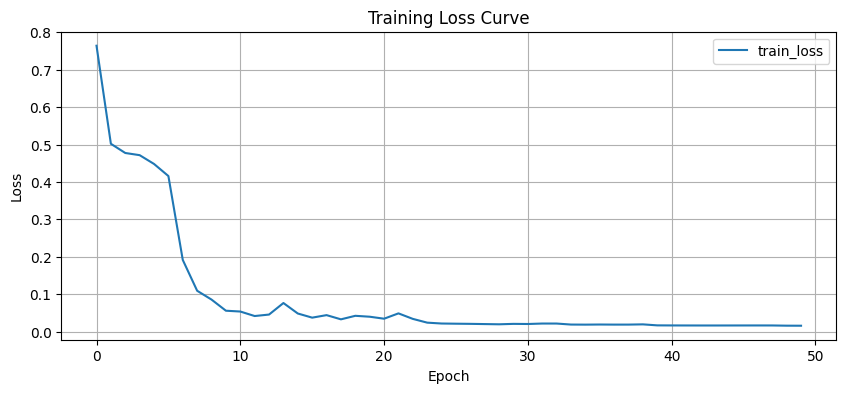


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.008510 | F1=0.2821
p=31.0% | thr=0.008810 | F1=0.2814
p=32.0% | thr=0.009064 | F1=0.2828
p=33.0% | thr=0.009309 | F1=0.2841
p=34.0% | thr=0.009574 | F1=0.2850
p=35.0% | thr=0.009871 | F1=0.2838
p=36.0% | thr=0.010094 | F1=0.2853
p=37.0% | thr=0.010299 | F1=0.2857
p=38.0% | thr=0.010442 | F1=0.2883
p=39.0% | thr=0.010578 | F1=0.2915
p=40.0% | thr=0.010717 | F1=0.2938
p=41.0% | thr=0.010863 | F1=0.2960
p=42.0% | thr=0.010981 | F1=0.2989
p=43.0% | thr=0.011132 | F1=0.3019
p=44.0% | thr=0.011236 | F1=0.3049
p=45.0% | thr=0.011371 | F1=0.3081
p=46.0% | thr=0.011499 | F1=0.3112
p=47.0% | thr=0.011634 | F1=0.3114
p=48.0% | thr=0.011760 | F1=0.3154
p=49.0% | thr=0.011865 | F1=0.3194
p=50.0% | thr=0.011987 | F1=0.3217
p=51.0% | thr=0.012083 | F1=0.3246
p=52.0% | thr=0.012222 | F1=0.3276
p=53.0% | thr=0.012364 | F1=0.3308
p=54.0% | thr=0.012479 | F1=0.3340
p=55.0% | thr=0.012584 | F1=0.3386
p=56.0% | thr=0.012769 | F1=0.3408
p=57.0% | thr=0.012915 | 

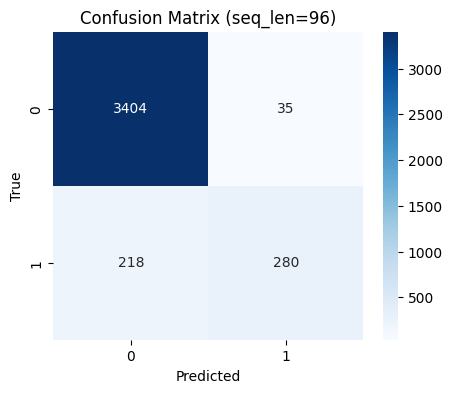


===== ISOLATION FOREST =====
IF -> P=0.6340 R=0.5984 F1=0.6157 ROC_AUC=0.8441 PR_AUC=0.6766


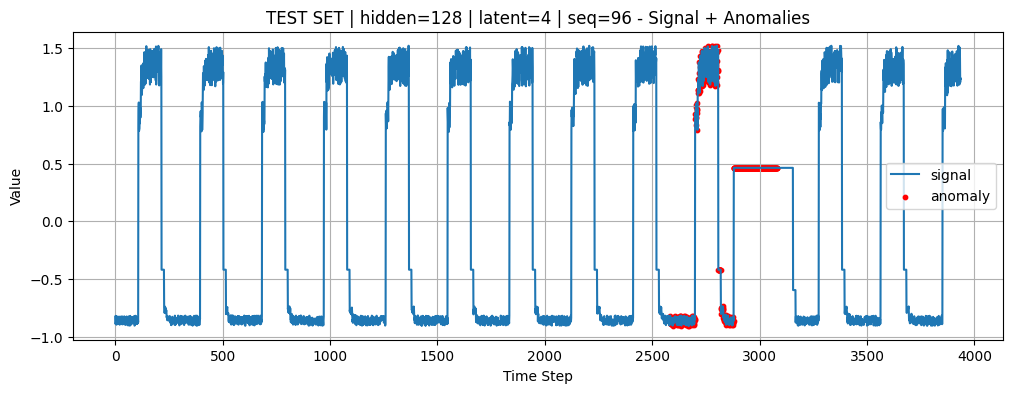

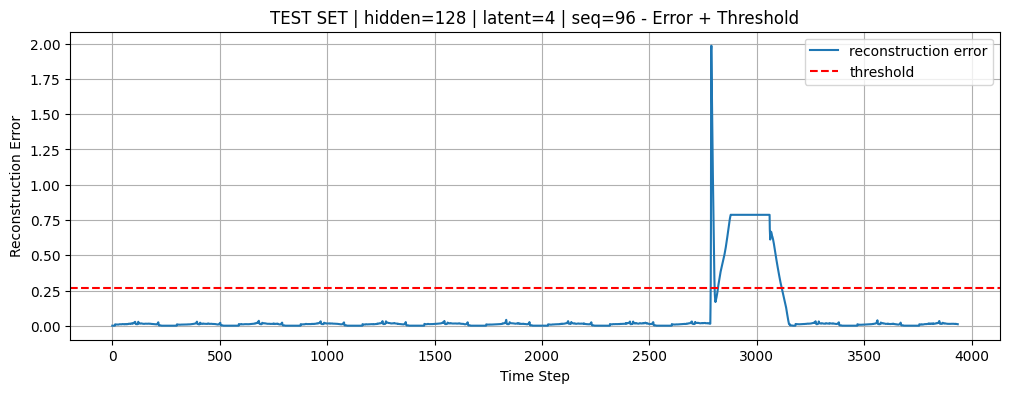


######## RUN 12/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(128)}
Epoch 1 | train_loss=0.97452 | lr=0.0010000
Epoch 2 | train_loss=0.84601 | lr=0.0010000
Epoch 3 | train_loss=0.79507 | lr=0.0010000
Epoch 4 | train_loss=0.72935 | lr=0.0010000
Epoch 5 | train_loss=0.66308 | lr=0.0010000
Epoch 6 | train_loss=0.61007 | lr=0.0010000
Epoch 7 | train_loss=0.39294 | lr=0.0010000
Epoch 8 | train_loss=0.22072 | lr=0.0010000
Epoch 9 | train_loss=0.17395 | lr=0.0010000
Epoch 10 | train_loss=0.08547 | lr=0.0010000
Epoch 11 | train_loss=0.06759 | lr=0.0010000
Epoch 12 | train_loss=0.08267 | lr=0.0010000
Epoch 13 | train_loss=0.06322 | lr=0.0010000
Epoch 14 | train_loss=0.05063 | lr=0.0010000
Epoch 15 | train_loss=0.04298 | lr=0.0010000
Epoch 16 | train_loss=0.05214 | lr=0.0010000
Epoch 17 | train_loss=0.04960 | lr=0.0010000
Epoch 18 | train_loss=0.03826 | lr=0.0010000
Epoch 19 | train_loss=0.04329 | lr=0.0010000
Epoch

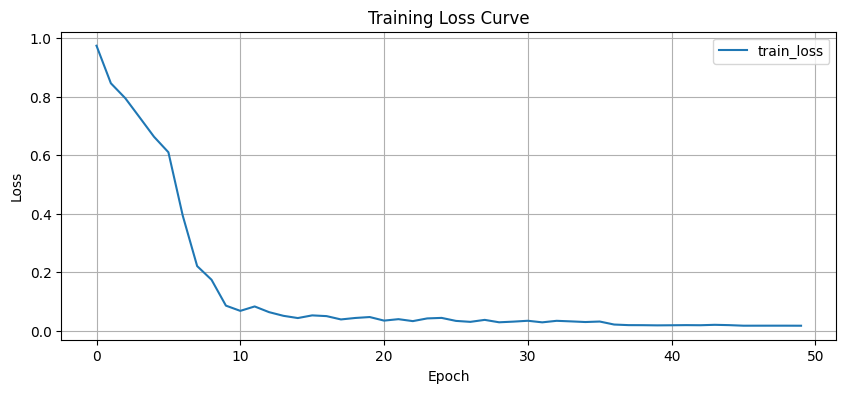


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.010173 | F1=0.2750
p=31.0% | thr=0.010301 | F1=0.2767
p=32.0% | thr=0.010403 | F1=0.2795
p=33.0% | thr=0.010538 | F1=0.2819
p=34.0% | thr=0.010642 | F1=0.2844
p=35.0% | thr=0.010791 | F1=0.2868
p=36.0% | thr=0.010886 | F1=0.2893
p=37.0% | thr=0.010977 | F1=0.2925
p=38.0% | thr=0.011062 | F1=0.2952
p=39.0% | thr=0.011146 | F1=0.2978
p=40.0% | thr=0.011258 | F1=0.3006
p=41.0% | thr=0.011403 | F1=0.3041
p=42.0% | thr=0.011571 | F1=0.3070
p=43.0% | thr=0.011701 | F1=0.3105
p=44.0% | thr=0.011811 | F1=0.3142
p=45.0% | thr=0.011958 | F1=0.3179
p=46.0% | thr=0.012119 | F1=0.3212
p=47.0% | thr=0.012270 | F1=0.3250
p=48.0% | thr=0.012417 | F1=0.3291
p=49.0% | thr=0.012569 | F1=0.3332
p=50.0% | thr=0.012762 | F1=0.3375
p=51.0% | thr=0.012933 | F1=0.3411
p=52.0% | thr=0.013099 | F1=0.3449
p=53.0% | thr=0.013316 | F1=0.3488
p=54.0% | thr=0.013433 | F1=0.3534
p=55.0% | thr=0.013562 | F1=0.3575
p=56.0% | thr=0.013706 | F1=0.3578
p=57.0% | thr=0.013892 | 

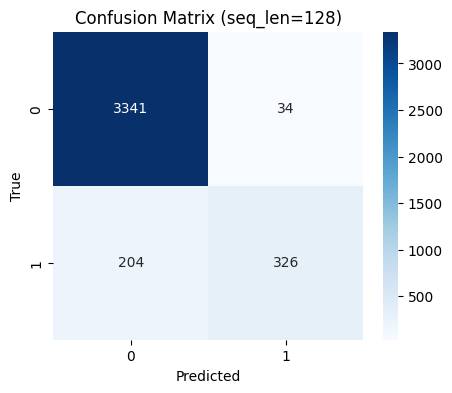


===== ISOLATION FOREST =====
IF -> P=0.6699 R=0.6472 F1=0.6583 ROC_AUC=0.8396 PR_AUC=0.7246


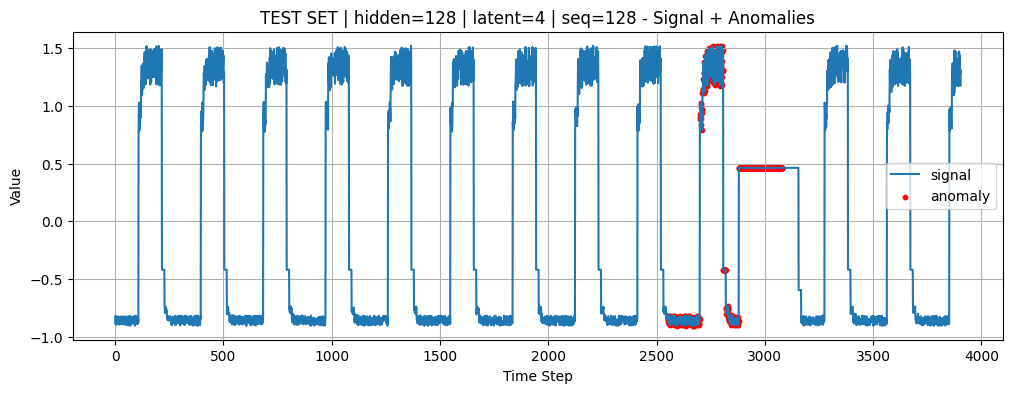

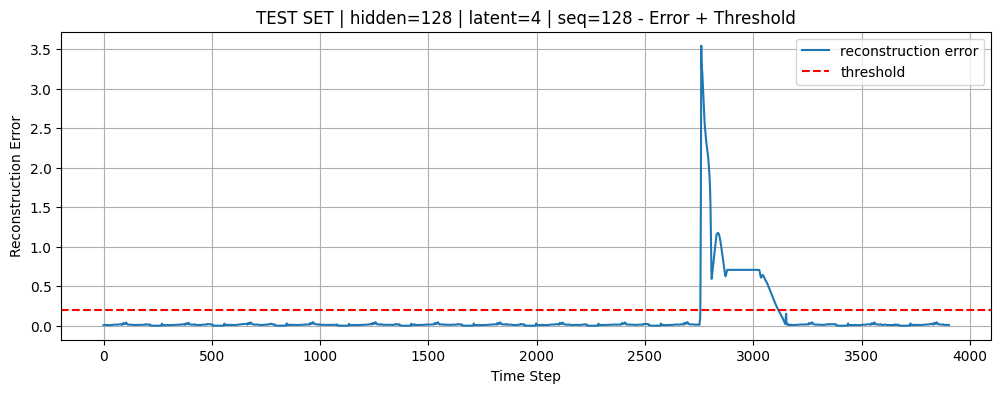


######## RUN 13/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(160)}
Epoch 1 | train_loss=1.06221 | lr=0.0010000
Epoch 2 | train_loss=1.03497 | lr=0.0010000
Epoch 3 | train_loss=0.93193 | lr=0.0010000
Epoch 4 | train_loss=0.90965 | lr=0.0010000
Epoch 5 | train_loss=0.89258 | lr=0.0010000
Epoch 6 | train_loss=0.93440 | lr=0.0010000
Epoch 7 | train_loss=0.98358 | lr=0.0010000
Epoch 8 | train_loss=0.98011 | lr=0.0010000
Epoch 9 | train_loss=0.97317 | lr=0.0005000
Epoch 10 | train_loss=0.99020 | lr=0.0005000
Epoch 11 | train_loss=0.88905 | lr=0.0005000
Epoch 12 | train_loss=0.87446 | lr=0.0005000
Epoch 13 | train_loss=0.85949 | lr=0.0005000
Epoch 14 | train_loss=0.83282 | lr=0.0005000
Epoch 15 | train_loss=0.72321 | lr=0.0005000
Epoch 16 | train_loss=0.66483 | lr=0.0005000
Epoch 17 | train_loss=0.63211 | lr=0.0005000
Epoch 18 | train_loss=0.61013 | lr=0.0005000
Epoch 19 | train_loss=0.59236 | lr=0.0005000
Epoch

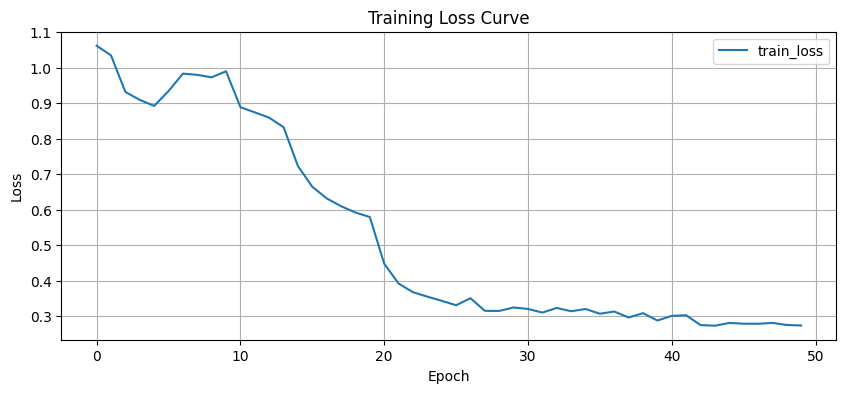


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.015264 | F1=0.2838
p=31.0% | thr=0.015707 | F1=0.2835
p=32.0% | thr=0.016317 | F1=0.2848
p=33.0% | thr=0.016958 | F1=0.2829
p=34.0% | thr=0.017677 | F1=0.2842
p=35.0% | thr=0.019251 | F1=0.2855
p=36.0% | thr=0.021161 | F1=0.2880
p=37.0% | thr=0.026954 | F1=0.2900
p=38.0% | thr=0.030620 | F1=0.2931
p=39.0% | thr=0.032095 | F1=0.2951
p=40.0% | thr=0.033186 | F1=0.2974
p=41.0% | thr=0.033681 | F1=0.2995
p=42.0% | thr=0.034253 | F1=0.3012
p=43.0% | thr=0.034777 | F1=0.3040
p=44.0% | thr=0.035237 | F1=0.3052
p=45.0% | thr=0.035747 | F1=0.3057
p=46.0% | thr=0.036195 | F1=0.3063
p=47.0% | thr=0.036853 | F1=0.3075
p=48.0% | thr=0.037322 | F1=0.3100
p=49.0% | thr=0.038095 | F1=0.3120
p=50.0% | thr=0.038880 | F1=0.3147
p=51.0% | thr=0.039680 | F1=0.3174
p=52.0% | thr=0.041127 | F1=0.3195
p=53.0% | thr=0.043402 | F1=0.3217
p=54.0% | thr=0.059275 | F1=0.3240
p=55.0% | thr=0.148937 | F1=0.3097
p=56.0% | thr=0.263531 | F1=0.3041
p=57.0% | thr=0.277147 | 

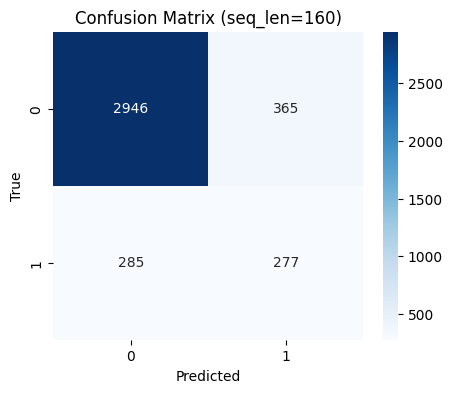


===== ISOLATION FOREST =====
IF -> P=0.6862 R=0.6459 F1=0.6654 ROC_AUC=0.8245 PR_AUC=0.7386


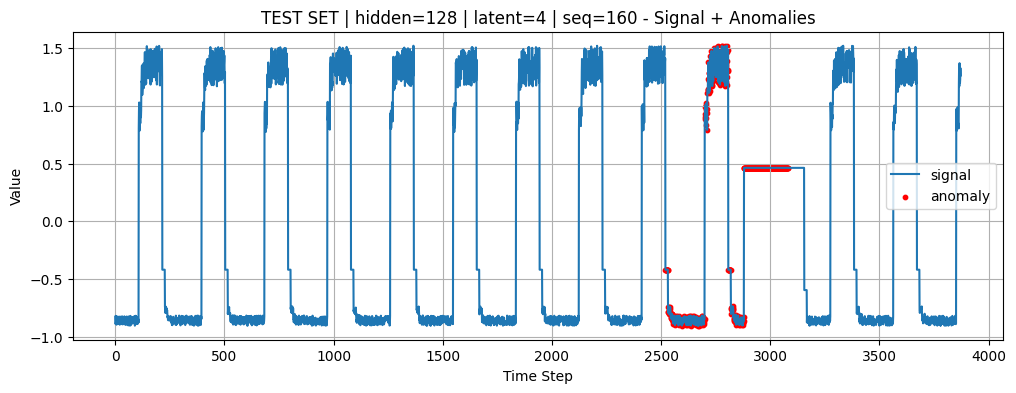

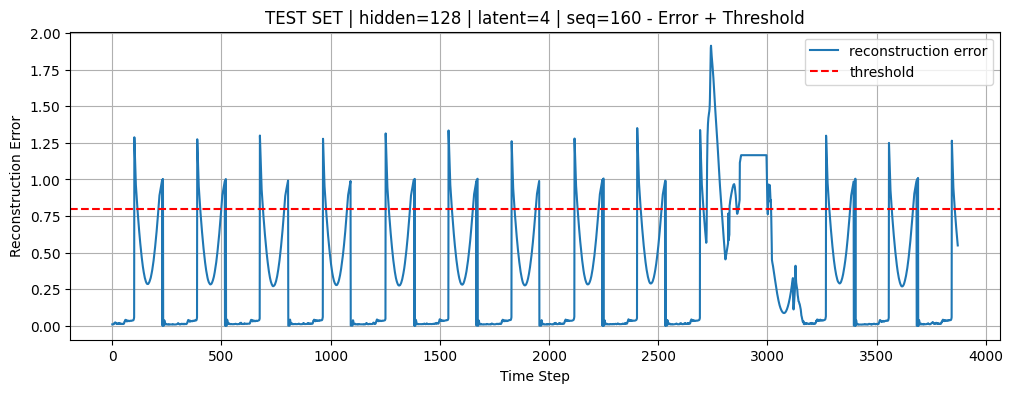


######## RUN 14/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(192)}
Epoch 1 | train_loss=1.04701 | lr=0.0010000
Epoch 2 | train_loss=1.03303 | lr=0.0010000
Epoch 3 | train_loss=1.00069 | lr=0.0010000
Epoch 4 | train_loss=0.97470 | lr=0.0010000
Epoch 5 | train_loss=0.96636 | lr=0.0010000
Epoch 6 | train_loss=1.04454 | lr=0.0010000
Epoch 7 | train_loss=1.05467 | lr=0.0010000
Epoch 8 | train_loss=1.04451 | lr=0.0010000
Epoch 9 | train_loss=1.04544 | lr=0.0005000
Epoch 10 | train_loss=1.03974 | lr=0.0005000
Epoch 11 | train_loss=1.03936 | lr=0.0005000
Epoch 12 | train_loss=1.03914 | lr=0.0005000
Epoch 13 | train_loss=1.03887 | lr=0.0002500
Epoch 14 | train_loss=1.03724 | lr=0.0002500
Epoch 15 | train_loss=1.03535 | lr=0.0002500
Epoch 16 | train_loss=1.03482 | lr=0.0002500
Epoch 17 | train_loss=1.04074 | lr=0.0001250
Epoch 18 | train_loss=1.02003 | lr=0.0001250
Epoch 19 | train_loss=1.02121 | lr=0.0001250
Epoch

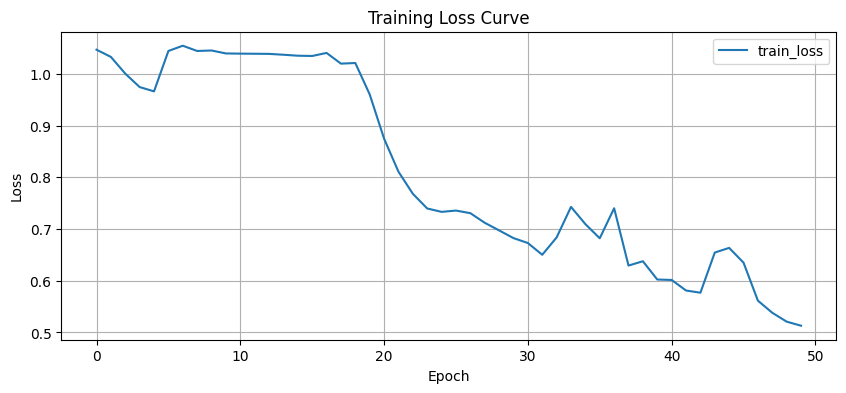


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.124714 | F1=0.2990
p=31.0% | thr=0.136872 | F1=0.3010
p=32.0% | thr=0.143098 | F1=0.3023
p=33.0% | thr=0.155037 | F1=0.3038
p=34.0% | thr=0.162417 | F1=0.3047
p=35.0% | thr=0.167913 | F1=0.3068
p=36.0% | thr=0.174977 | F1=0.3083
p=37.0% | thr=0.185231 | F1=0.3094
p=38.0% | thr=0.196896 | F1=0.3115
p=39.0% | thr=0.221442 | F1=0.3137
p=40.0% | thr=0.260116 | F1=0.3149
p=41.0% | thr=0.301735 | F1=0.3166
p=42.0% | thr=0.326312 | F1=0.3115
p=43.0% | thr=0.351370 | F1=0.3103
p=44.0% | thr=0.360616 | F1=0.3091
p=45.0% | thr=0.368967 | F1=0.3115
p=46.0% | thr=0.376913 | F1=0.3139
p=47.0% | thr=0.386514 | F1=0.3170
p=48.0% | thr=0.403567 | F1=0.3177
p=49.0% | thr=0.420241 | F1=0.3165
p=50.0% | thr=0.434719 | F1=0.3128
p=51.0% | thr=0.444261 | F1=0.3134
p=52.0% | thr=0.459844 | F1=0.3094
p=53.0% | thr=0.475911 | F1=0.3067
p=54.0% | thr=0.493278 | F1=0.3038
p=55.0% | thr=0.512001 | F1=0.2995
p=56.0% | thr=0.531148 | F1=0.2993
p=57.0% | thr=0.552946 | 

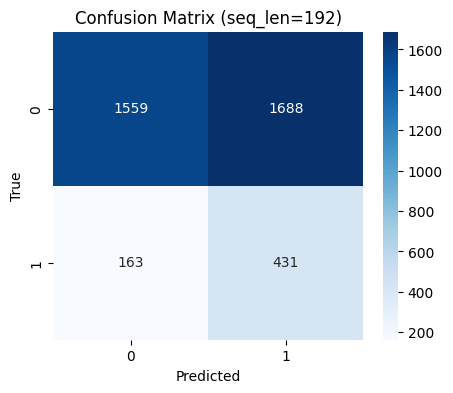


===== ISOLATION FOREST =====
IF -> P=0.7155 R=0.6902 F1=0.7027 ROC_AUC=0.8343 PR_AUC=0.7590


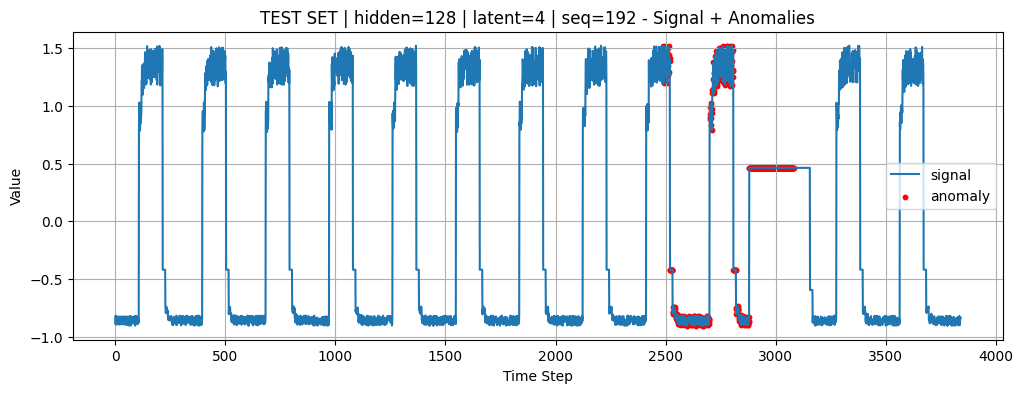

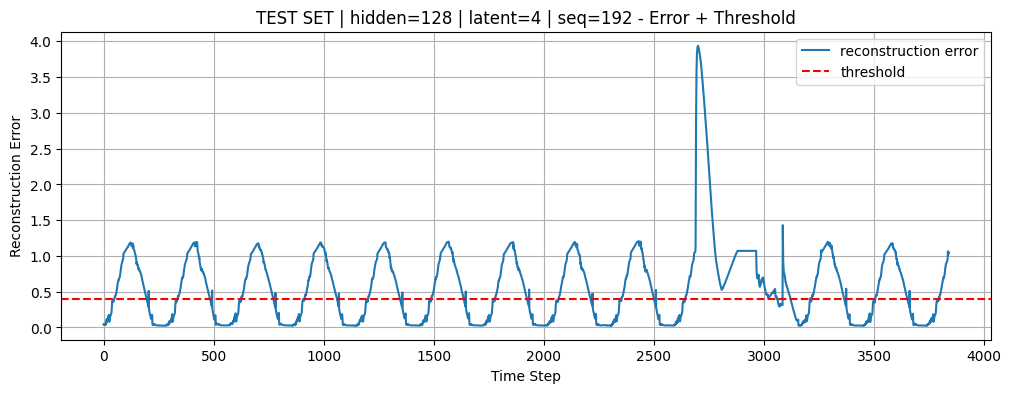


######## RUN 15/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(224)}
Epoch 1 | train_loss=1.04806 | lr=0.0010000
Epoch 2 | train_loss=1.03708 | lr=0.0010000
Epoch 3 | train_loss=1.03425 | lr=0.0010000
Epoch 4 | train_loss=1.03318 | lr=0.0010000
Epoch 5 | train_loss=1.02371 | lr=0.0010000
Epoch 6 | train_loss=1.02308 | lr=0.0010000
Epoch 7 | train_loss=1.03671 | lr=0.0010000
Epoch 8 | train_loss=1.02170 | lr=0.0010000
Epoch 9 | train_loss=0.97905 | lr=0.0010000
Epoch 10 | train_loss=0.81720 | lr=0.0010000
Epoch 11 | train_loss=0.69166 | lr=0.0010000
Epoch 12 | train_loss=0.76177 | lr=0.0010000
Epoch 13 | train_loss=0.74509 | lr=0.0010000
Epoch 14 | train_loss=0.66612 | lr=0.0010000
Epoch 15 | train_loss=0.55949 | lr=0.0010000
Epoch 16 | train_loss=0.59564 | lr=0.0010000
Epoch 17 | train_loss=0.48664 | lr=0.0010000
Epoch 18 | train_loss=0.37734 | lr=0.0010000
Epoch 19 | train_loss=0.39571 | lr=0.0010000
Epoch

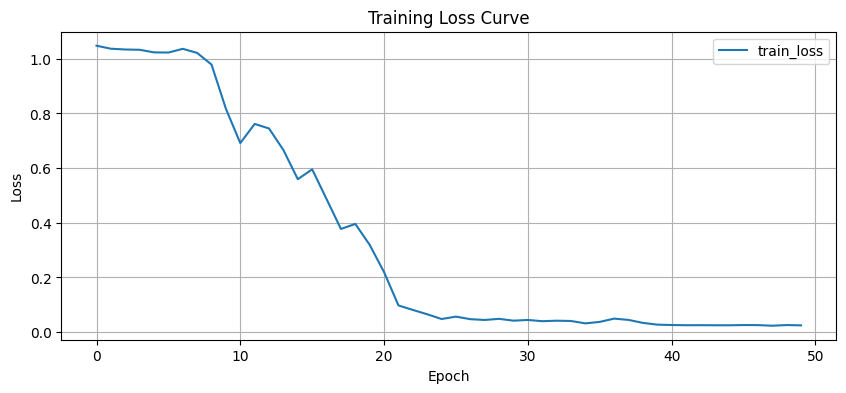


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.016770 | F1=0.3295
p=31.0% | thr=0.016947 | F1=0.3326
p=32.0% | thr=0.017100 | F1=0.3358
p=33.0% | thr=0.017277 | F1=0.3386
p=34.0% | thr=0.017491 | F1=0.3417
p=35.0% | thr=0.017672 | F1=0.3451
p=36.0% | thr=0.017830 | F1=0.3485
p=37.0% | thr=0.017985 | F1=0.3520
p=38.0% | thr=0.018114 | F1=0.3556
p=39.0% | thr=0.018251 | F1=0.3591
p=40.0% | thr=0.018354 | F1=0.3618
p=41.0% | thr=0.018463 | F1=0.3645
p=42.0% | thr=0.018614 | F1=0.3651
p=43.0% | thr=0.018791 | F1=0.3657
p=44.0% | thr=0.018952 | F1=0.3669
p=45.0% | thr=0.019107 | F1=0.3697
p=46.0% | thr=0.019235 | F1=0.3727
p=47.0% | thr=0.019371 | F1=0.3746
p=48.0% | thr=0.019524 | F1=0.3771
p=49.0% | thr=0.019698 | F1=0.3808
p=50.0% | thr=0.019873 | F1=0.3829
p=51.0% | thr=0.020030 | F1=0.3867
p=52.0% | thr=0.020168 | F1=0.3901
p=53.0% | thr=0.020372 | F1=0.3912
p=54.0% | thr=0.020523 | F1=0.3948
p=55.0% | thr=0.020742 | F1=0.3991
p=56.0% | thr=0.020914 | F1=0.4020
p=57.0% | thr=0.021157 | 

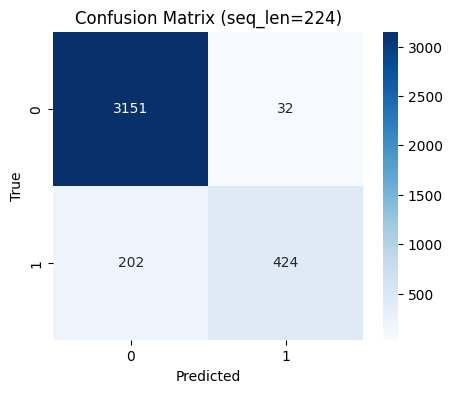


===== ISOLATION FOREST =====
IF -> P=0.7297 R=0.6901 F1=0.7094 ROC_AUC=0.8188 PR_AUC=0.7512


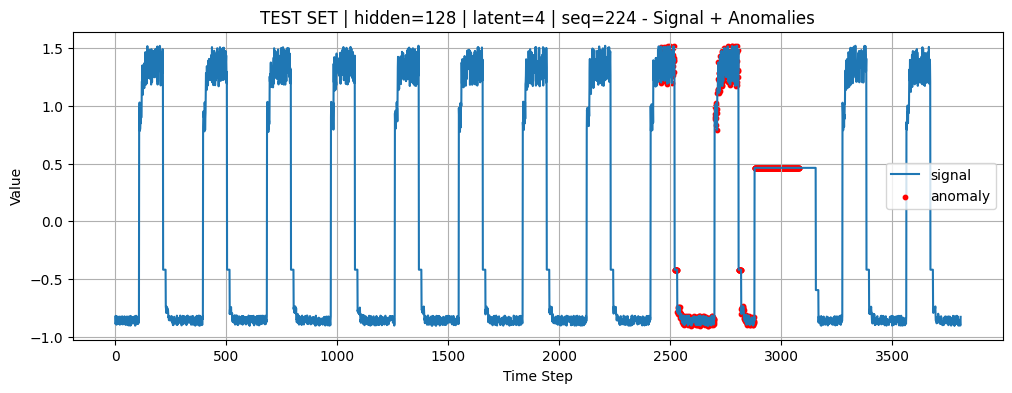

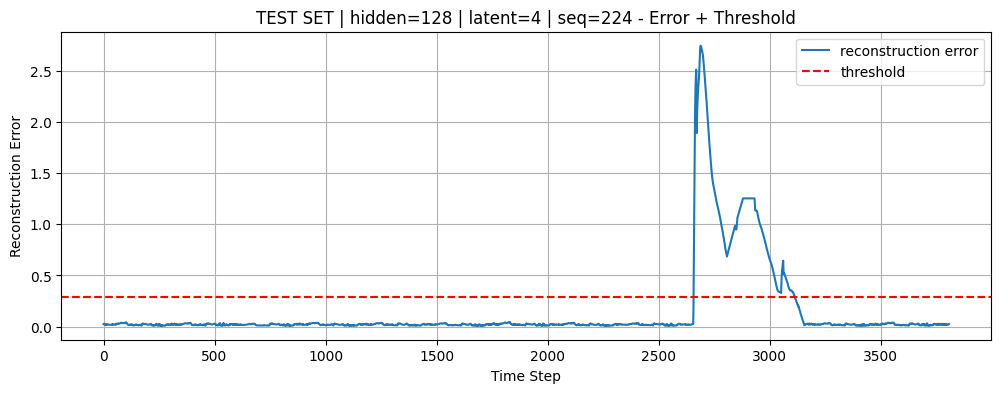


######## RUN 16/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(256)}
Epoch 1 | train_loss=1.05225 | lr=0.0010000
Epoch 2 | train_loss=1.04735 | lr=0.0010000
Epoch 3 | train_loss=1.04481 | lr=0.0010000
Epoch 4 | train_loss=1.04323 | lr=0.0010000
Epoch 5 | train_loss=1.02517 | lr=0.0010000
Epoch 6 | train_loss=1.02903 | lr=0.0010000
Epoch 7 | train_loss=1.02255 | lr=0.0010000
Epoch 8 | train_loss=1.01533 | lr=0.0010000
Epoch 9 | train_loss=1.04367 | lr=0.0010000
Epoch 10 | train_loss=1.05115 | lr=0.0010000
Epoch 11 | train_loss=1.04218 | lr=0.0010000
Epoch 12 | train_loss=1.03158 | lr=0.0005000
Epoch 13 | train_loss=1.01517 | lr=0.0005000
Epoch 14 | train_loss=1.01759 | lr=0.0005000
Epoch 15 | train_loss=1.00397 | lr=0.0005000
Epoch 16 | train_loss=1.00096 | lr=0.0005000
Epoch 17 | train_loss=0.99785 | lr=0.0005000
Epoch 18 | train_loss=0.97192 | lr=0.0005000
Epoch 19 | train_loss=0.95724 | lr=0.0005000
Epoch

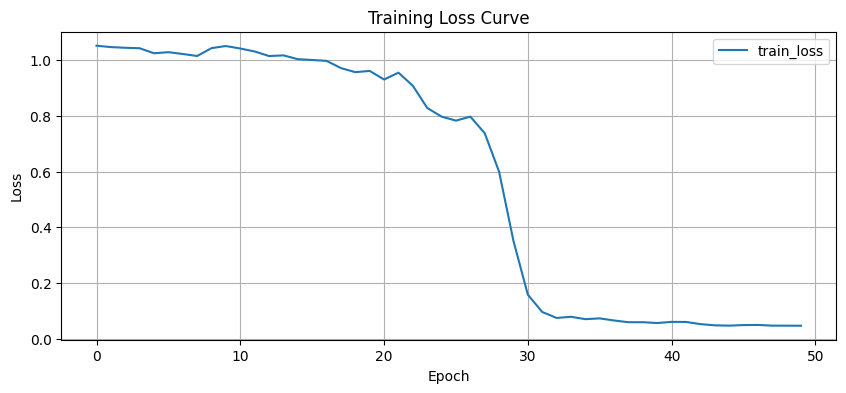


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.027564 | F1=0.3597
p=31.0% | thr=0.027735 | F1=0.3629
p=32.0% | thr=0.027900 | F1=0.3658
p=33.0% | thr=0.028065 | F1=0.3677
p=34.0% | thr=0.028299 | F1=0.3712
p=35.0% | thr=0.028488 | F1=0.3742
p=36.0% | thr=0.028685 | F1=0.3773
p=37.0% | thr=0.028856 | F1=0.3809
p=38.0% | thr=0.029041 | F1=0.3840
p=39.0% | thr=0.029202 | F1=0.3874
p=40.0% | thr=0.029373 | F1=0.3907
p=41.0% | thr=0.029548 | F1=0.3946
p=42.0% | thr=0.029751 | F1=0.3981
p=43.0% | thr=0.029911 | F1=0.4016
p=44.0% | thr=0.030083 | F1=0.4057
p=45.0% | thr=0.030257 | F1=0.4101
p=46.0% | thr=0.030427 | F1=0.4138
p=47.0% | thr=0.030619 | F1=0.4171
p=48.0% | thr=0.030823 | F1=0.4211
p=49.0% | thr=0.031057 | F1=0.4240
p=50.0% | thr=0.031251 | F1=0.4271
p=51.0% | thr=0.031386 | F1=0.4313
p=52.0% | thr=0.031584 | F1=0.4350
p=53.0% | thr=0.031789 | F1=0.4382
p=54.0% | thr=0.031958 | F1=0.4427
p=55.0% | thr=0.032110 | F1=0.4461
p=56.0% | thr=0.032286 | F1=0.4480
p=57.0% | thr=0.032478 | 

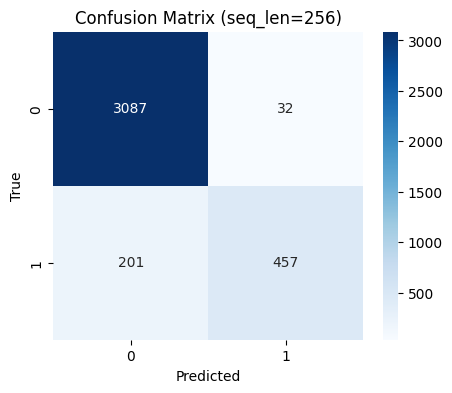


===== ISOLATION FOREST =====
IF -> P=0.7443 R=0.6900 F1=0.7161 ROC_AUC=0.8128 PR_AUC=0.7534


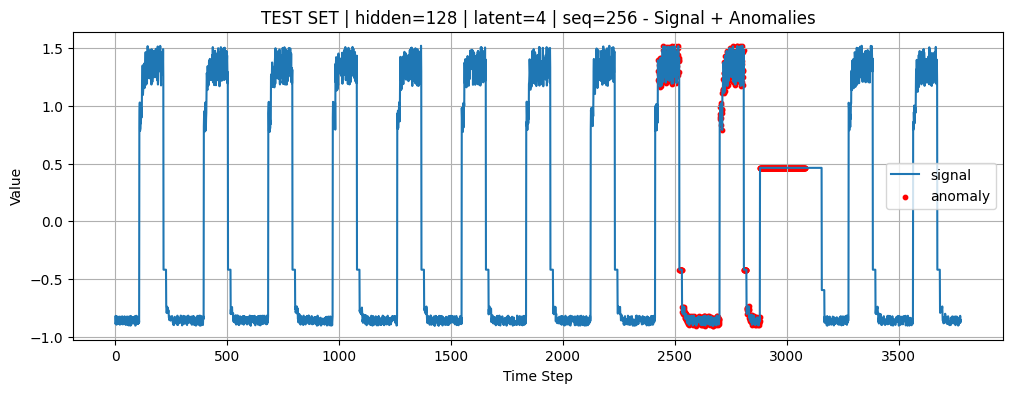

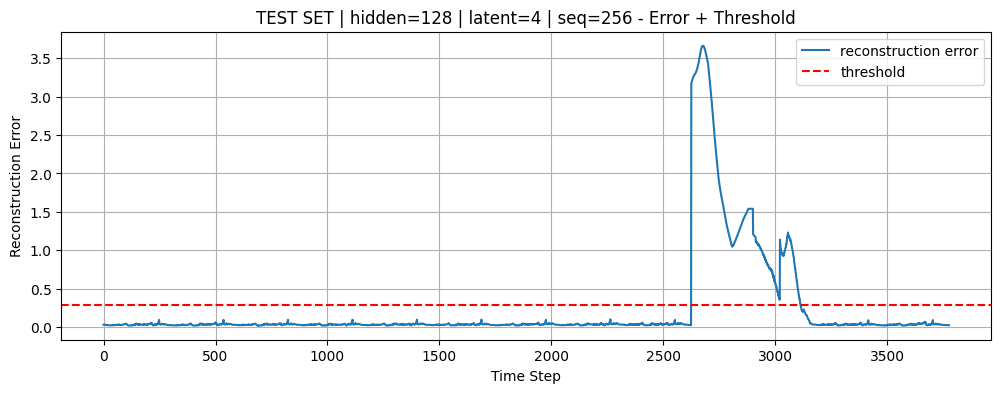


######## RUN 17/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(288)}
Epoch 1 | train_loss=1.05789 | lr=0.0010000
Epoch 2 | train_loss=1.03785 | lr=0.0010000
Epoch 3 | train_loss=1.03710 | lr=0.0010000
Epoch 4 | train_loss=1.00431 | lr=0.0010000
Epoch 5 | train_loss=1.00121 | lr=0.0010000
Epoch 6 | train_loss=0.99071 | lr=0.0010000
Epoch 7 | train_loss=0.99549 | lr=0.0010000
Epoch 8 | train_loss=0.98089 | lr=0.0010000
Epoch 9 | train_loss=0.96443 | lr=0.0010000
Epoch 10 | train_loss=0.94482 | lr=0.0010000
Epoch 11 | train_loss=0.92870 | lr=0.0010000
Epoch 12 | train_loss=0.88463 | lr=0.0010000
Epoch 13 | train_loss=0.86724 | lr=0.0010000
Epoch 14 | train_loss=0.87057 | lr=0.0010000
Epoch 15 | train_loss=0.85687 | lr=0.0010000
Epoch 16 | train_loss=0.85153 | lr=0.0010000
Epoch 17 | train_loss=0.90531 | lr=0.0010000
Epoch 18 | train_loss=0.84013 | lr=0.0010000
Epoch 19 | train_loss=0.76887 | lr=0.0010000
Epoch

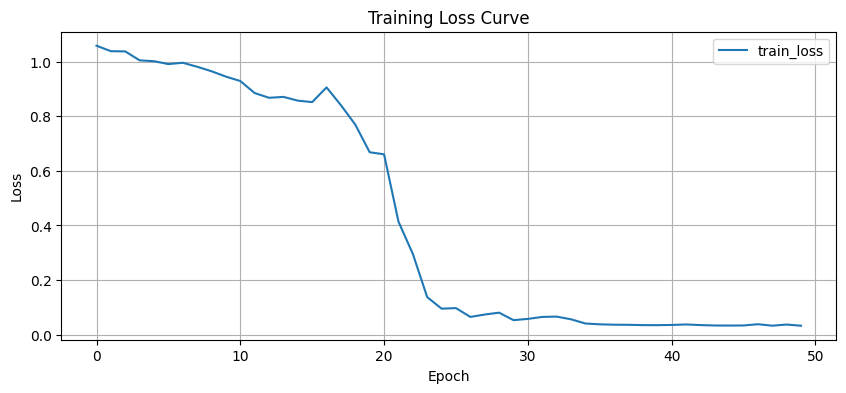


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.020407 | F1=0.3710
p=31.0% | thr=0.020469 | F1=0.3728
p=32.0% | thr=0.020562 | F1=0.3747
p=33.0% | thr=0.020640 | F1=0.3766
p=34.0% | thr=0.020730 | F1=0.3796
p=35.0% | thr=0.020802 | F1=0.3816
p=36.0% | thr=0.020912 | F1=0.3808
p=37.0% | thr=0.020969 | F1=0.3828
p=38.0% | thr=0.021042 | F1=0.3855
p=39.0% | thr=0.021091 | F1=0.3888
p=40.0% | thr=0.021187 | F1=0.3920
p=41.0% | thr=0.021274 | F1=0.3954
p=42.0% | thr=0.021359 | F1=0.3987
p=43.0% | thr=0.021440 | F1=0.4028
p=44.0% | thr=0.021528 | F1=0.4062
p=45.0% | thr=0.021603 | F1=0.4089
p=46.0% | thr=0.021710 | F1=0.4119
p=47.0% | thr=0.021793 | F1=0.4163
p=48.0% | thr=0.021883 | F1=0.4201
p=49.0% | thr=0.021986 | F1=0.4247
p=50.0% | thr=0.022118 | F1=0.4282
p=51.0% | thr=0.022200 | F1=0.4328
p=52.0% | thr=0.022301 | F1=0.4365
p=53.0% | thr=0.022423 | F1=0.4402
p=54.0% | thr=0.022551 | F1=0.4447
p=55.0% | thr=0.022639 | F1=0.4485
p=56.0% | thr=0.022769 | F1=0.4532
p=57.0% | thr=0.022877 | 

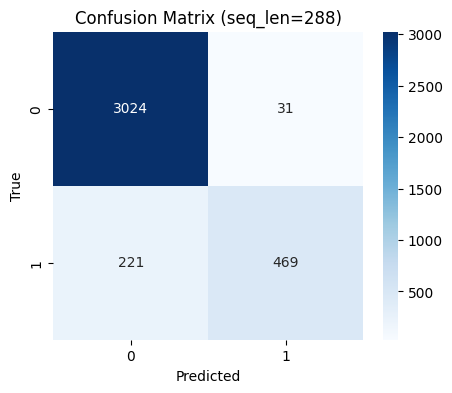


===== ISOLATION FOREST =====
IF -> P=0.7594 R=0.7000 F1=0.7285 ROC_AUC=0.8425 PR_AUC=0.7764


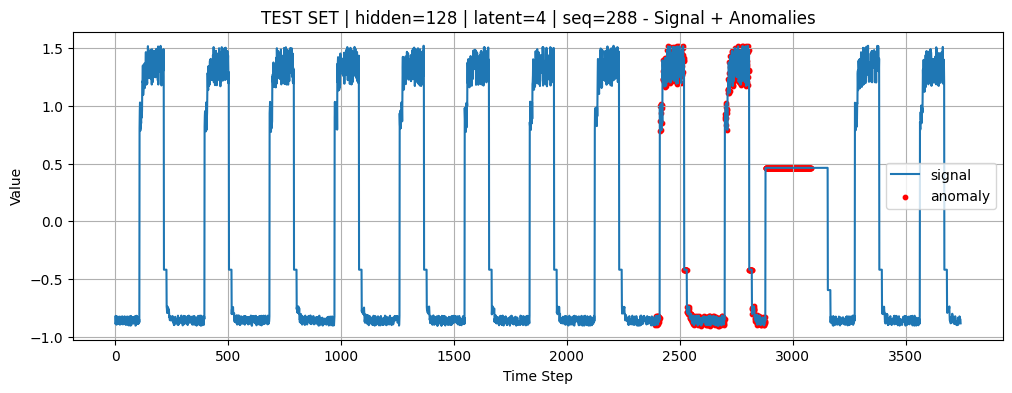

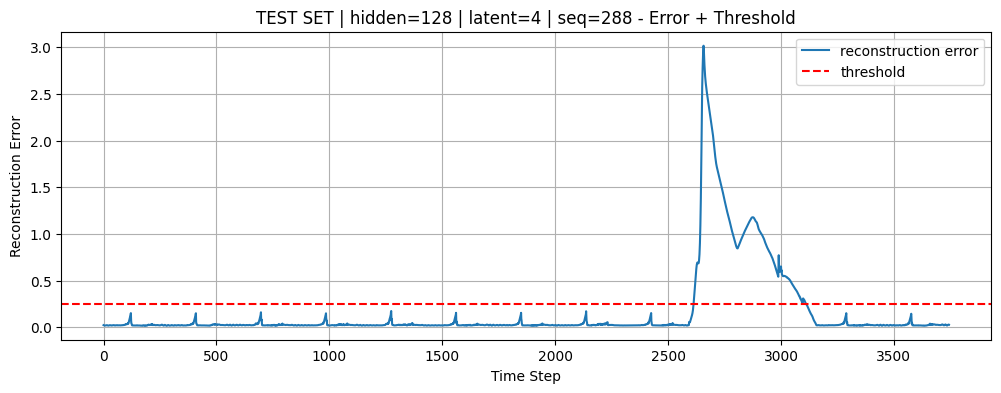


######## RUN 18/18 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': np.int64(320)}
Epoch 1 | train_loss=1.04959 | lr=0.0010000
Epoch 2 | train_loss=1.04800 | lr=0.0010000
Epoch 3 | train_loss=1.04607 | lr=0.0010000
Epoch 4 | train_loss=1.04253 | lr=0.0010000
Epoch 5 | train_loss=1.01471 | lr=0.0010000
Epoch 6 | train_loss=0.96399 | lr=0.0010000
Epoch 7 | train_loss=0.94974 | lr=0.0010000
Epoch 8 | train_loss=0.94075 | lr=0.0010000
Epoch 9 | train_loss=0.89056 | lr=0.0010000
Epoch 10 | train_loss=0.85651 | lr=0.0010000
Epoch 11 | train_loss=0.82964 | lr=0.0010000
Epoch 12 | train_loss=0.65453 | lr=0.0010000
Epoch 13 | train_loss=0.53476 | lr=0.0010000
Epoch 14 | train_loss=0.70387 | lr=0.0010000
Epoch 15 | train_loss=0.40580 | lr=0.0010000
Epoch 16 | train_loss=0.33701 | lr=0.0010000
Epoch 17 | train_loss=0.26968 | lr=0.0010000
Epoch 18 | train_loss=0.37781 | lr=0.0010000
Epoch 19 | train_loss=0.48783 | lr=0.0010000
Epoch

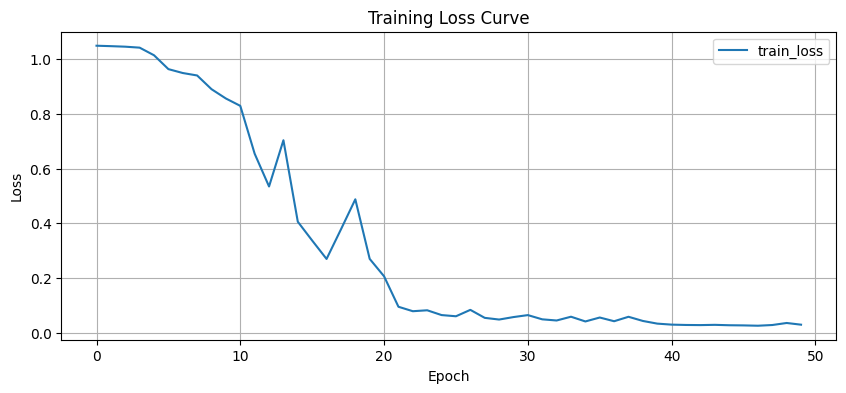


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.015648 | F1=0.3900
p=31.0% | thr=0.015716 | F1=0.3928
p=32.0% | thr=0.015797 | F1=0.3953
p=33.0% | thr=0.015880 | F1=0.3960
p=34.0% | thr=0.015969 | F1=0.3976
p=35.0% | thr=0.016045 | F1=0.4002
p=36.0% | thr=0.016133 | F1=0.4034
p=37.0% | thr=0.016227 | F1=0.4056
p=38.0% | thr=0.016311 | F1=0.4084
p=39.0% | thr=0.016446 | F1=0.4097
p=40.0% | thr=0.016536 | F1=0.4131
p=41.0% | thr=0.016635 | F1=0.4144
p=42.0% | thr=0.016745 | F1=0.4169
p=43.0% | thr=0.016841 | F1=0.4209
p=44.0% | thr=0.016961 | F1=0.4246
p=45.0% | thr=0.017048 | F1=0.4288
p=46.0% | thr=0.017177 | F1=0.4326
p=47.0% | thr=0.017312 | F1=0.4359
p=48.0% | thr=0.017429 | F1=0.4393
p=49.0% | thr=0.017543 | F1=0.4423
p=50.0% | thr=0.017641 | F1=0.4453
p=51.0% | thr=0.017777 | F1=0.4488
p=52.0% | thr=0.017903 | F1=0.4530
p=53.0% | thr=0.018026 | F1=0.4552
p=54.0% | thr=0.018197 | F1=0.4585
p=55.0% | thr=0.018305 | F1=0.4636
p=56.0% | thr=0.018490 | F1=0.4682
p=57.0% | thr=0.018687 | 

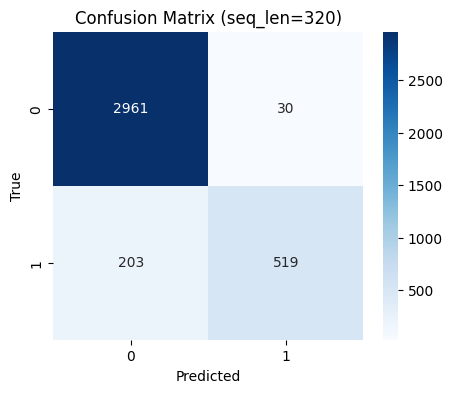


===== ISOLATION FOREST =====
IF -> P=0.7660 R=0.6801 F1=0.7205 ROC_AUC=0.8624 PR_AUC=0.7908


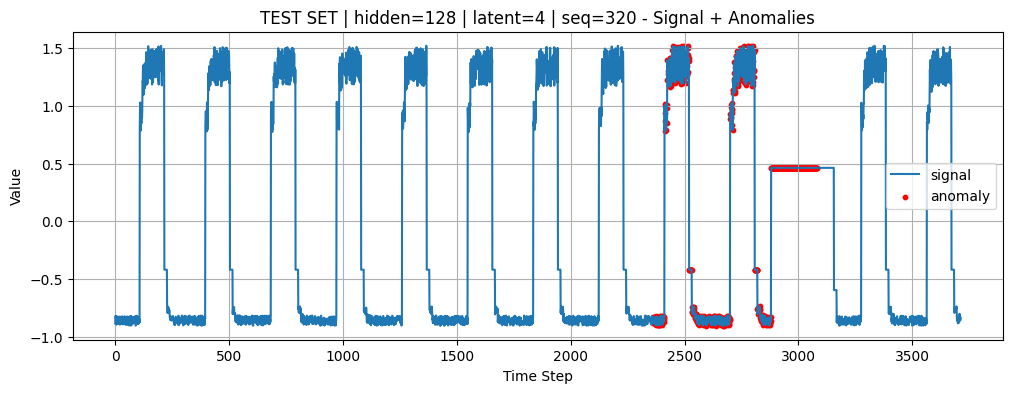

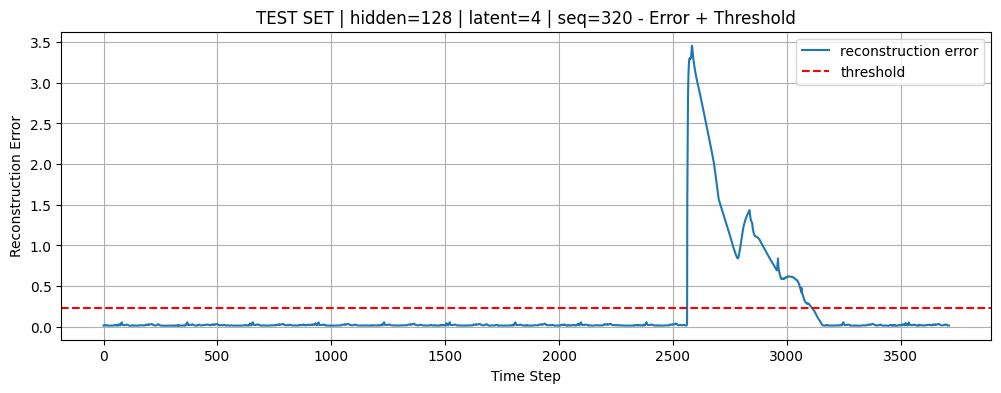


================ FINAL SUMMARY =================
   hidden_dim latent_dim num_layers seq_len  threshold  precision    recall  \
0          64          4          1      64   0.050132   0.784195  0.553648   
1          64          4          1      96   0.259767   0.893939  0.592369   
2          64          4          1     128   0.205327   0.905292  0.613208   
3          64          4          1     160   0.250641   0.913924  0.642349   
4          64          4          1     192   0.304741   0.921241  0.649832   
5          64          4          1     224   0.345738   0.868852  0.677316   
6          64          4          1     256   0.319422   0.934560  0.694529   
7          64          4          1     288   0.252758   0.938976  0.691304   
8          64          4          1     320   0.779807   0.295424  0.608033   
9         128          4          1      64   0.022610   0.305941  0.663090   
10        128          4          1      96   0.267741   0.888889  0.562249   
11

In [30]:
# ---- MAIN ----
# Entry point for full anomaly detection pipeline:
# - Device selection (CPU/GPU)
# - Reproducibility setup
# - Data loading
# - Label construction
# - Hyperparameter search execution

if __name__ == "__main__":

    # ---- Device Selection ----
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("DEVICE:", device)

    # ---- Reproducibility ----
    set_seed(42)

    # ---- Load Time-Series Data ----
    df = load_series(
        "../assets/data/art_daily_flatmiddle.csv"
    )

    # ---- Load Anomaly Windows ----
    windows = load_windows(
        "../assets/labels/combined_windows.json",
        "artificialWithAnomaly/art_daily_flatmiddle.csv"
    )

    # ---- Build Ground Truth Labels ----
    df = build_labels(df, windows)

    # ---- Run Full Hyperparameter Search ----
    final_results = search(df, device)